Código adaptado de:

[1] D. Foster, Generative Deep Learning: Teaching Machines to Paint, Write, Compose, and Play, Second Edition, O'Reilly, 2023.

[2] P. Lippe, Deep Energy-Based Generative Models' tutorial, disponível no [(link)](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html).

[3] Jakub M. Tomczak. Deep Generative Modeling, Springer, 2024.

# Importações

In [1]:
!pip install torchinfo

In [2]:
import os
import numpy as np                                          # arrays numéricos e álgebra linear; base p/ operações vetorizadas
import matplotlib.pyplot as plt                             # gráficos e visualização de imagens (imshow, scatter, etc.)
import torch                                                # core do PyTorch: tensores + autodiff (backprop)
import torch.nn as nn                                       # módulos e camadas de rede (nn.Conv2d, nn.Linear, etc.)
import torch.optim as optim                                 # otimizadores (Adam, SGD, etc.) p/ atualizar pesos via gradientes
from torch.utils.data import DataLoader                     # loader que entrega mini-lotes (permite embaralhamento e paralelização)
import random                                               # aleatoriedade (ex: amostra do buffer de replay)
from torchinfo import summary                               # resumo da arquitetura: shapes, params e multiplies-adds
from torchvision.datasets import USPS, MNIST, FashionMNIST  # conjuntos de dados (imagens)
from torchvision import transforms                          # pipeline de pré-processamento (ToTensor, Normalize, etc.)

In [3]:
os.makedirs("output", exist_ok=True)

# Hiperparâmetros

In [4]:
IMAGE_SIZE = 16        # tamanho da imagem (H=W=16): USPS usa 16x16; MNIST/Fashion: 28x28 (seriam redimensionados)
CHANNELS   = 1         # imagens em tons de cinza: 1 canal (B,C,H,W)

STEP_SIZE = 5          # tamanho do passo na dinâmica de Langevin (magnitude da atualização no espaço das imagens)
STEPS = 60             # número de iterações de Langevin para refinar amostras
NOISE = 0.005          # desvio padrão do ruído gaussiano adicionado a cada passo

ALPHA = 0.1            # peso da regularização de energia
GRADIENT_CLIP = 0.005  # limite absoluto no gradiente da imagem

BATCH_SIZE = 128       # tamanho do mini-lote
BUFFER_SIZE = 8192     # capacidade do buffer (mantém até 8192 amostras para contraste)

LEARNING_RATE = 0.0001 # taxa de aprendizado do otimizador (Adam)
EPOCHS = 60            # número total de épocas de treinamento

DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
# seleciona GPU (Torch Accelerate) se disponível; caso contrário, CPU

print("Acelerador disponível:", torch.accelerator.is_available())
# True/False — verifica se a API accelerator encontrou GPU

print("Tipo do acelerador:", torch.accelerator.current_accelerator().type)
# nome simbólico do dispositivo (ex: cuda, cpu, mps no Mac)

print("GPUs detectadas:", [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
# lista nomes das GPUs CUDA detectadas (vazio se não houver)

Acelerador disponível: True
Tipo do acelerador: cuda
GPUs detectadas: ['NVIDIA GeForce RTX 4060 Ti']


# Funções utilitárias

In [5]:
def sample_batch(loader):                                            # obtém 1 lote de um DataLoader PyTorch
    batch = next(iter(loader))                                       # pega o próximo mini-lote do loader
    if isinstance(batch, (tuple, list)):                             # se loader retorna (imagens, rótulos), pegamos só imagens
        batch = batch[0]                                             # seleciona o tensor de imagens (primeiro elemento)
    return batch                                                     # retorna o lote como tensor (PyTorch já usa tensor)


def display(images, n=10, size=(20, 3), cmap="gray_r", save_to=None):# exibe n imagens com opções simples
    images = images.detach().cpu().numpy()                           # move pro CPU e vira numpy para plotar
    if images.max() > 1.0:                                           # normaliza se valores estão em [0,255]
        images = images / 255.0                                      # mapeia para [0,1]
    elif images.min() < 0.0:                                         # normaliza se valores estão em [-1,1]
        images = (images + 1.0) / 2.0                                # mapeia para [0,1]

    plt.figure(figsize=size)                                         # cria figura
    for i in range(n):                                               # loop para n exemplos
        plt.subplot(1, n, i + 1)                                     # cria subplot
        img = images[i].squeeze()                                    # remove canais desnecessários
        plt.imshow(img, cmap=cmap)                                   # plota imagem em escala de cinza
        plt.axis("off")                                              # remove eixos

    if save_to:                                                      # se caminho fornecido
        plt.savefig(save_to)                                         # salva a figura
        print(f"\nSaved to {save_to}")                               # feedback no console

    plt.show()                                                       # mostra figura

# Dados

In [10]:
!wget -nc https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/multiclass/usps.bz2 -P ./data
!wget -nc https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/multiclass/usps.t.bz2 -P ./data

'wget' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.
'wget' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [11]:
# Transformação: converte para tensor ∈ [0,1], depois normaliza para [-1,1]
transform = transforms.Compose([                 # pipeline sequencial de transformações
    transforms.ToTensor(),                       # PIL/NumPy -> tensor float32 (C,H,W) em [0,1]
    transforms.Normalize((0.5,), (0.5,))         # aplica (x - 0.5)/0.5 -> mapeia [0,1] -> [-1,1]
])

# Carrega USPS treinamento/teste
train_ds = USPS(root="./data", train=True,  download=False, transform=transform)  # dataset treino (imgs→tensor[-1,1])
test_ds  = USPS(root="./data", train=False, download=False, transform=transform)  # dataset teste

# DataLoaders (iteradores de mini-batches)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # entrega batches (B,C,H,W) - embaralha p/ treinamento
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)  # sem embaralhamento (avaliação determinística)

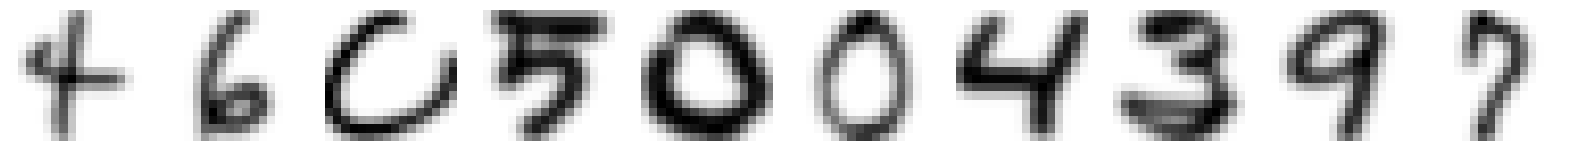

In [12]:
# mostra algumas imagens do conjunto de treinamento
train_sample = sample_batch(train_dl)        # obtém 1 mini-lote do DataLoader: tensor (B,C,H,W) em [-1,1]
display(train_sample)                        # exibe imagens

# Rede Neural

In [13]:
ConvNet = nn.Sequential(
    nn.Conv2d(CHANNELS, 32, kernel_size=3, stride=1, padding=1),  # (B,1,16,16) -> (B,32,16,16)
    nn.SiLU(),                                                     # ativação SiLU (swish)
    nn.MaxPool2d(2),                                              # (B,32,16,16) -> (B,32,8,8) reduz resolução pela metade
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),        # (B,32,8,8) -> (B,64,8,8)
    nn.SiLU(),                                                     # ativação SiLU (swish)
    nn.MaxPool2d(2),                                              # (B,64,8,8) -> (B,64,4,4) reduz resolução pela metade
)


EBMNet = nn.Sequential(
    ConvNet,
    nn.Flatten(),                                              # (B,64,4,4) -> (B, 64*4*4) vetoriza features
    nn.Linear(64 * 4 * 4, 512),                                # camada densa inicial: features -> 512
    nn.SiLU(),                                                 # ativação SiLU (swish)
    nn.Linear(512, 512),                                       # camadas densas
    nn.SiLU(),
    nn.Linear(512, 1)                                          # saída escalar: valor de energia E(x)
)

In [14]:
# instancia o modelo EBMNet: rede que mapeia imagem (B,1,16,16) -> escalar de energia E(x)
model = EBMNet.to(DEVICE)                                      # cria o modelo no device selecionado (GPU se disponível, senão CPU)

In [15]:
# imprime arquitetura detalhada para inspeção: camadas, tensores, parâmetros, custo computacional
summary(
    EBMNet,
    input_size=(1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE),         # shape de entrada: 1 imagem (B=1), CxHxW
    col_names=(
        "input_size", "output_size", "num_params",            # mostra shapes por camada e número de parâmetros
        "params_percent", "kernel_size", "mult_adds",         # % dos params tot., tamanho kernels, FLOPs aprox
        "trainable"                                           # indica se os pesos são treináveis
    )
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Param %                   Kernel Shape              Mult-Adds                 Trainable
Sequential                               [1, 1, 16, 16]            [1, 1]                    --                             --                   --                        --                        True
├─Sequential: 1-1                        [1, 1, 16, 16]            [1, 64, 4, 4]             --                             --                   --                        --                        True
│    └─Conv2d: 2-1                       [1, 1, 16, 16]            [1, 32, 16, 16]           320                         0.04%                   [3, 3]                    81,920                    True
│    └─SiLU: 2-2                         [1, 32, 16, 16]           [1, 32, 16, 16]           --                             --                   --                        --              

# Geração de amostras via Dinâmica de Langevin

In [16]:
def generate_samples(model, inp_imgs, steps, step_size, noise, return_img_per_step=False):
    imgs_per_step = []                                             # armazena imagens a cada passo (T,B,C,H,W) p/ visualização

    inp_imgs = inp_imgs.clone().detach().to(DEVICE)                # copia p/ evitar efeitos colaterais + move p/ GPU/CPU
    inp_imgs.requires_grad = True                                  # habilita gradiente p/ computar ∇_x E(x)

    for _ in range(steps):                                         # loop de Langevin (T passos)
        noise_tensor = torch.randn_like(inp_imgs) * noise          # ruído ~ N(0,noise^2); mesmo shape (B,C,H,W)
        inp_imgs = inp_imgs + noise_tensor                         # x ← x + ruído (exploração no espaço da imagem)
        inp_imgs = torch.clip(inp_imgs, -1.0, 1.0)                 # mantém valores no intervalo válido [-1,1]

        out_score = model(inp_imgs).sum()                          # energia total (soma → escalar p/ backward)
                                                                   # Eθ(x) escalar → precisamos ∂E/∂x
        grads = torch.autograd.grad(out_score, inp_imgs)[0]        # ∇_x Eθ(x): gradiente da energia em relação à imagem
        grads = torch.clip(grads, -GRADIENT_CLIP, GRADIENT_CLIP)   # evita exploding gradients no espaço de pixels

        inp_imgs = inp_imgs + step_size * grads                    # Dinâmica de Langevin: x ← x + α ∇_x Eθ(x)

        inp_imgs = torch.clip(inp_imgs, -1.0, 1.0)                 # limita valores após atualização (mantém domínio válido)

        inp_imgs = inp_imgs.detach()                               # corta grafo - evita acumular histórico
        inp_imgs.requires_grad = True                              # reabilita grad p/ próximo passo (novo grafo)

        if return_img_per_step:                                    # animação do processo
            imgs_per_step.append(inp_imgs.cpu())                   # armazena snapshot (move p/ CPU p/ economizar VRAM)

    if return_img_per_step:                                        # retorna (T,B,C,H,W) p/ animação
        return torch.stack(imgs_per_step, dim=0)
    else:
        return inp_imgs                                            # retorna apenas última imagem (B,C,H,W)


# Buffer para armazenar e refinar amostras via Langevin

In [17]:
class Buffer:
    def __init__(self, model):                                                         # construtor do buffer
        super().__init__()
        self.model = model                                                             # referência ao EBM

        # inicializa buffer com ruído ~ U[-1,1], shape: (1,C,H,W) por item
        self.examples = [
            (torch.rand(1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) * 2 - 1)    # (1,C,H,W) amostra aleatória
            for _ in range(BATCH_SIZE)
        ]

    def sample_new_examples(self, steps, step_size, noise, batch_size):                                   # gera b amostras refinadas
        b = batch_size                                                                                    # alias do tamanho desejado (B)

        n_new = np.random.binomial(b, 0.05)                                                               # ~5% amostras novas p/ diversidade

        # gera n_new imagens novas aleatórias ∈ [-1,1], shape: (n_new,C,H,W)
        rand_imgs = torch.rand(n_new, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) * 2 - 1

        # escolhe (b - n_new) exemplos do buffer (reuso de amostras antigas)
        old_imgs = torch.cat(                                                                             # concatena lista de tensores
            random.choices(self.examples, k=b - n_new), dim=0                                             # escolhe com reposição
        ) if (b - n_new) > 0 else torch.empty(0, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)

        # concatena novas + antigas -> shape final: (b,C,H,W)
        inp_imgs = torch.cat([rand_imgs, old_imgs], dim=0)

        # Dinâmica de Langevin para mover as imagens em direção a regiões de alta probabilidade
        inp_imgs = generate_samples(self.model, inp_imgs, steps=steps, step_size=step_size, noise=noise)  # output shape: (b,C,H,W)

        # adiciona as novas amostras refinadas ao início do buffer
        # unsqueeze(0) → garante shape consistente (1,C,H,W) por item
        self.examples = [t.unsqueeze(0) for t in inp_imgs] + self.examples

        # mantém o tamanho do buffer limitado
        self.examples = self.examples[:BUFFER_SIZE]

        return inp_imgs                                                                                   # retorna batch refinado (b,C,H,W)

# Callback

In [18]:
class ImageGenerator:
    def __init__(self, ebm, num_img=10):
        self.ebm = ebm                                  # objeto EBM
        self.num_img = num_img                          # número de imagens a gerar ao final de cada época

    def on_epoch_end(self, epoch):
        # amostras iniciais ~ U[-1,1], shape: (num_img, C, H, W)
        start_imgs = torch.rand(self.num_img, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) * 2 - 1    # mapeia [0,1] -> [-1,1]

        # gera imagens via Langevin
        gen = generate_samples(
            self.ebm.model,                             # EBM para computar energia
            start_imgs,                                 # ruído como ponto inicial
            steps=1000,                                 # passos de Langevin (número de passos grande para convergir)
            step_size=STEP_SIZE,
            noise=NOISE
        )

        # salva/mostra imagens geradas ao final da época
        display(gen.cpu(), save_to=f"./output/generated_img_{epoch:03d}.png")

# Classe do modelo baseado em energia

In [19]:
class EBM:
    def __init__(self, model):                                      # construtor recebe o modelo
        self.model = model                                          # referência ao EBM (mapa x -> Eθ(x))
        self.buffer = Buffer(self.model)                            # replay buffer p/ amostras negativas persistentes
        self.alpha = ALPHA                                          # peso da regularização de energia
        self.optimizer = optim.Adam(self.model.parameters(),        # otimizador Adam p/ atualizar parâmetros θ
                                   lr=LEARNING_RATE)                # taxa de aprendizado

    def train_step(self, real_imgs):                                 # executa um passo de treinamento (1 mini-lote)
        self.model.train()                                           # modo de treinamento (ativa dropout/bn se houver)
        real_imgs = real_imgs.to(DEVICE)                             # (B,C,H,W) -> device
        b = real_imgs.shape[0]                                       # B = tamanho do mini-lote
        real_imgs += torch.randn_like(real_imgs) * NOISE             # data augmentation na imagem
        real_imgs = torch.clip(real_imgs, -1.0, 1.0)                 # mantém domínio de pixel em [-1,1]

        fake_imgs = self.buffer.sample_new_examples(                 # gera exatamente B amostras negativas
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE,           # Langevin curto
            batch_size=b
        )                                                            # (B,C,H,W)

        inp_imgs = torch.cat([real_imgs, fake_imgs], dim=0)          # concatena positivos+negativos -> (2B,C,H,W)
        out = self.model(inp_imgs)                                   # forward -> energias (2B,1)
        real_out = out[:b]                                           # primeiras B linhas = reais   -> (B,1)
        fake_out = out[b:]                                           # últimas   B linhas = falsas  -> (B,1)

        cdiv_loss = fake_out.mean(dim=0) - real_out.mean(dim=0)      # contrastive divergence: ↑ E(fake) e ↓ E(real)
        reg_loss = self.alpha * ((real_out**2 + fake_out**2).mean(dim=0))  # penaliza energias grandes (controle de escala)
        loss = cdiv_loss + reg_loss                                  # função de perda total (escalar)

        self.optimizer.zero_grad()                                   # zera gradientes acumulados
        loss.backward()                                              # backprop em θ via ∂E/∂θ
        self.optimizer.step()                                        # atualiza parâmetros θ

        return {
            "loss": float(loss.detach().cpu()),                      # loss total
            "reg": float(reg_loss.detach().cpu()),                   # termo de regularização
            "cdiv": float(cdiv_loss.detach().cpu()),                 # termo de contraste
            "real": float(real_out.mean().detach().cpu()),           # média E(real) (deve diminuir ao longo do treinamento)
            "fake": float(fake_out.mean().detach().cpu()),           # média E(fake) (deve aumentar ao longo do treinamento)
        }

    @torch.no_grad()                                                 # desativa grad p/ avaliação
    def test_step(self, real_imgs):
        self.model.eval()                                            # modo avaliação
        real_imgs = real_imgs.to(DEVICE)                             # (B,C,H,W) -> device
        b = real_imgs.shape[0]                                       # B
        fake_imgs = (                                                # negativos simples p/ validação (sem buffer)
            torch.rand(b, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) * 2 - 1
        )                                                            # (B,C,H,W) ~ U[-1,1]

        inp_imgs = torch.cat([real_imgs, fake_imgs], dim=0)          # (2B,C,H,W)
        out = self.model(inp_imgs)                                   # (2B,1)
        real_out, fake_out = out[:b], out[b:]                        # particiona (B,1), (B,1)

        cdiv = fake_out.mean(dim=0) - real_out.mean(dim=0)           # métrica de contraste (sem reg)
        return {                                                     # retorna métricas escalares p/ logging
            "cdiv": float(cdiv.detach().cpu()),
            "real": float(real_out.mean().detach().cpu()),
            "fake": float(fake_out.mean().detach().cpu()),
        }


In [20]:
ebm = EBM(model)

# Treinamento

[Epoch 001] train: loss=-0.0109 reg=0.0015 cdiv=-0.0124 real=0.0696 fake=0.0571 | val: cdiv=-0.5834 real=0.0390 fake=-0.5445

Saved to ./output/generated_img_001.png


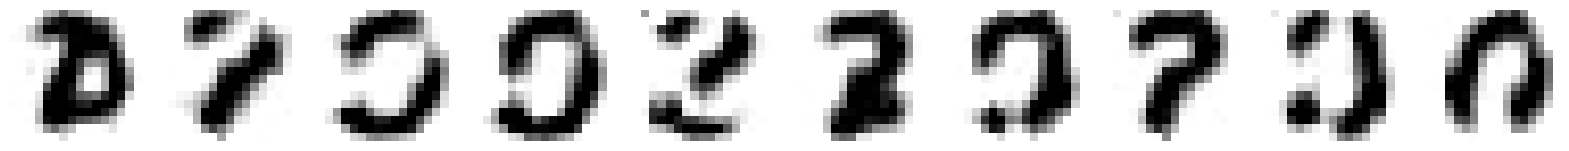

[Epoch 002] train: loss=0.0073 reg=0.0003 cdiv=0.0070 real=-0.0034 fake=0.0036 | val: cdiv=-0.2931 real=-0.0054 fake=-0.2985

Saved to ./output/generated_img_002.png


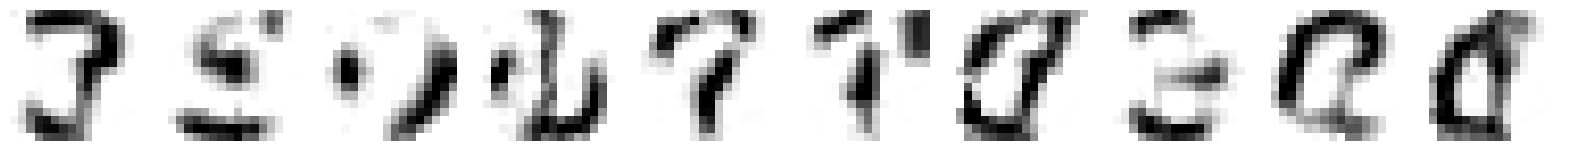

[Epoch 003] train: loss=0.0006 reg=0.0001 cdiv=0.0005 real=-0.0024 fake=-0.0019 | val: cdiv=-0.2597 real=-0.0030 fake=-0.2627

Saved to ./output/generated_img_003.png


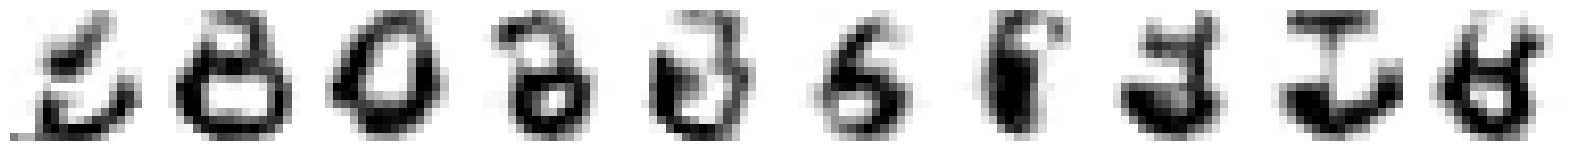

[Epoch 004] train: loss=-0.0006 reg=0.0001 cdiv=-0.0007 real=0.0048 fake=0.0041 | val: cdiv=-0.3110 real=0.0137 fake=-0.2973

Saved to ./output/generated_img_004.png


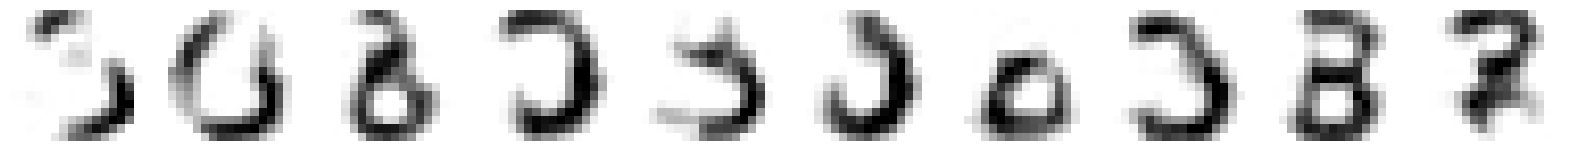

[Epoch 005] train: loss=0.0003 reg=0.0002 cdiv=0.0001 real=0.0082 fake=0.0083 | val: cdiv=-0.3085 real=0.0099 fake=-0.2986

Saved to ./output/generated_img_005.png


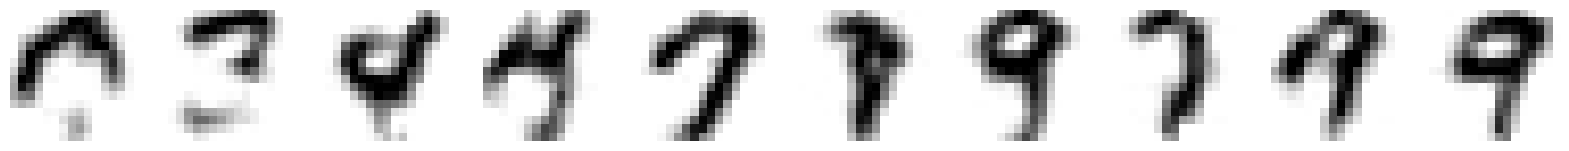

[Epoch 006] train: loss=-0.0006 reg=0.0002 cdiv=-0.0008 real=0.0058 fake=0.0051 | val: cdiv=-0.3274 real=-0.0117 fake=-0.3391

Saved to ./output/generated_img_006.png


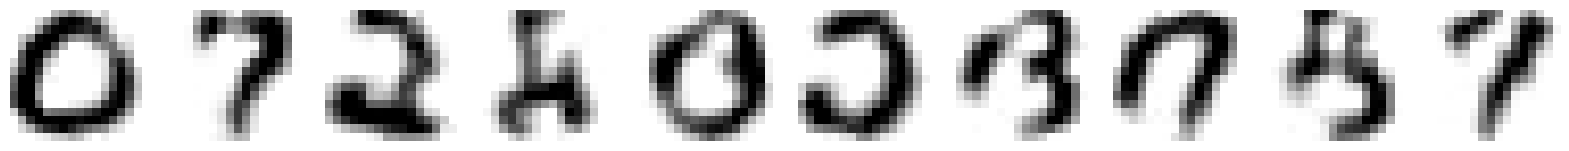

[Epoch 007] train: loss=-0.0001 reg=0.0001 cdiv=-0.0003 real=0.0034 fake=0.0031 | val: cdiv=-0.3574 real=-0.0030 fake=-0.3605

Saved to ./output/generated_img_007.png


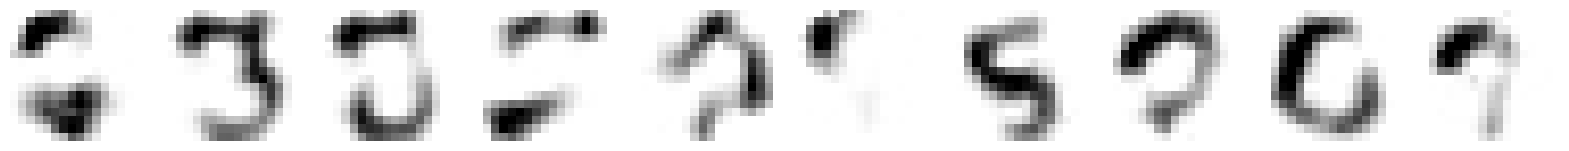

[Epoch 008] train: loss=-0.0005 reg=0.0001 cdiv=-0.0006 real=0.0027 fake=0.0021 | val: cdiv=-0.3969 real=0.0069 fake=-0.3900

Saved to ./output/generated_img_008.png


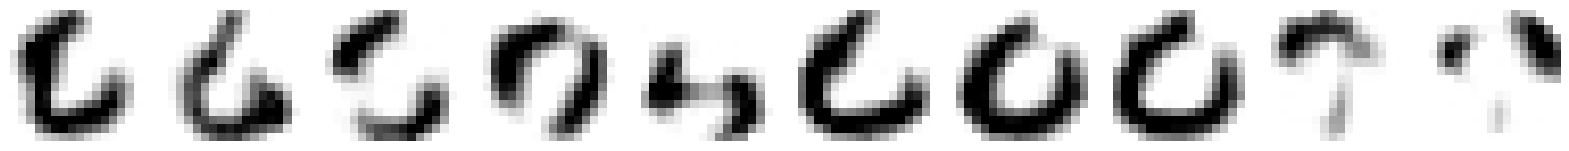

[Epoch 009] train: loss=-0.0005 reg=0.0001 cdiv=-0.0006 real=0.0059 fake=0.0053 | val: cdiv=-0.4153 real=0.0051 fake=-0.4102

Saved to ./output/generated_img_009.png


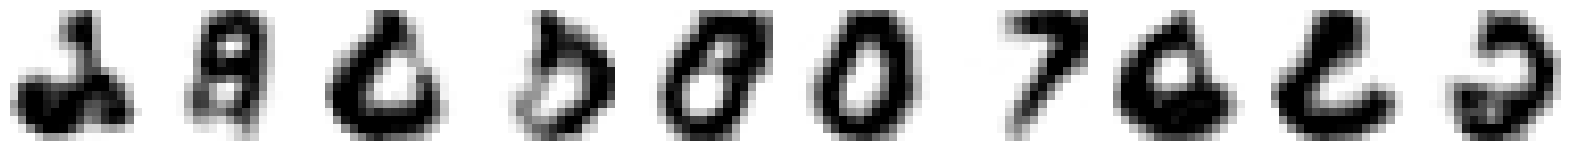

[Epoch 010] train: loss=-0.0005 reg=0.0001 cdiv=-0.0006 real=0.0026 fake=0.0021 | val: cdiv=-0.4268 real=-0.0054 fake=-0.4322

Saved to ./output/generated_img_010.png


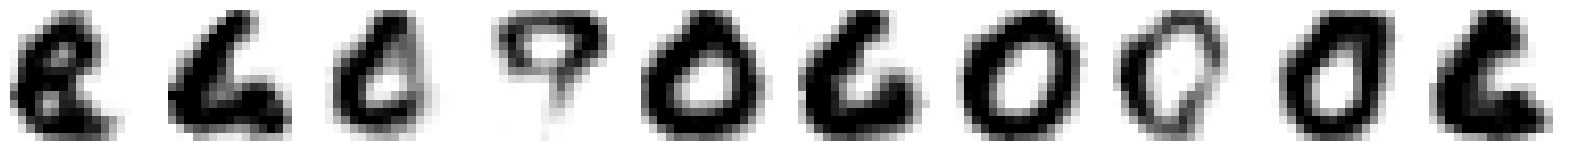

[Epoch 011] train: loss=0.0000 reg=0.0001 cdiv=-0.0001 real=0.0047 fake=0.0045 | val: cdiv=-0.4933 real=-0.0056 fake=-0.4988

Saved to ./output/generated_img_011.png


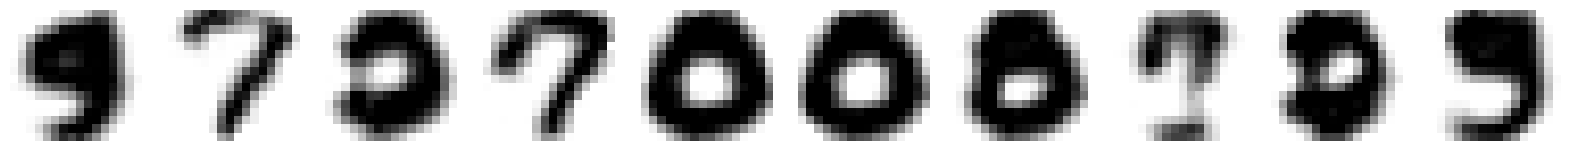

[Epoch 012] train: loss=-0.0000 reg=0.0001 cdiv=-0.0001 real=0.0030 fake=0.0029 | val: cdiv=-0.5344 real=0.0064 fake=-0.5281

Saved to ./output/generated_img_012.png


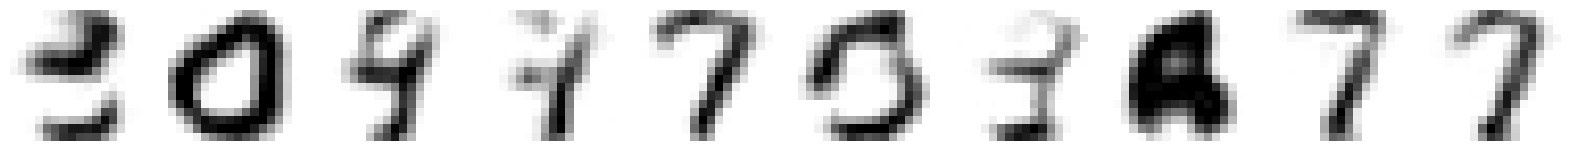

[Epoch 013] train: loss=0.0002 reg=0.0001 cdiv=0.0001 real=0.0013 fake=0.0014 | val: cdiv=-0.5984 real=0.0246 fake=-0.5739

Saved to ./output/generated_img_013.png


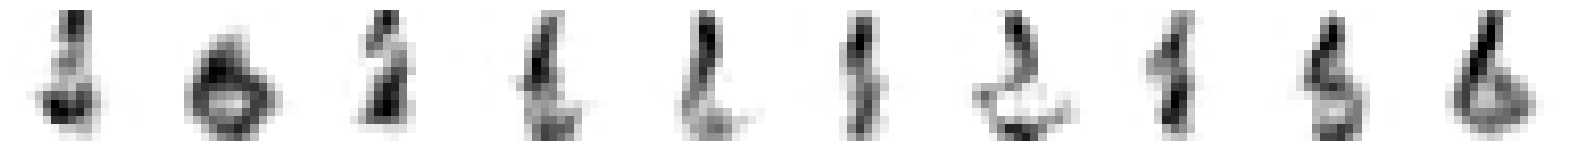

[Epoch 014] train: loss=0.0004 reg=0.0001 cdiv=0.0003 real=0.0010 fake=0.0013 | val: cdiv=-0.5753 real=0.0084 fake=-0.5670

Saved to ./output/generated_img_014.png


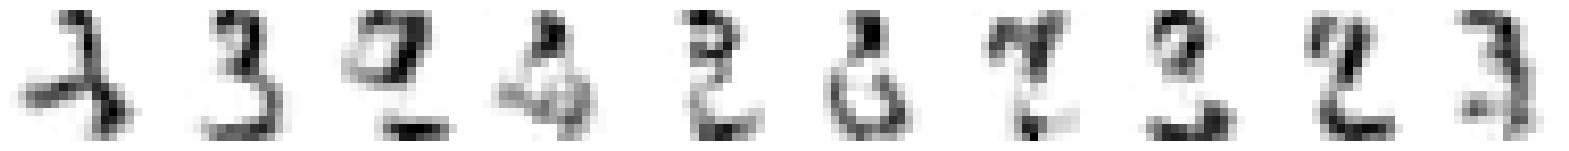

[Epoch 015] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0011 fake=0.0011 | val: cdiv=-0.5966 real=0.0022 fake=-0.5944

Saved to ./output/generated_img_015.png


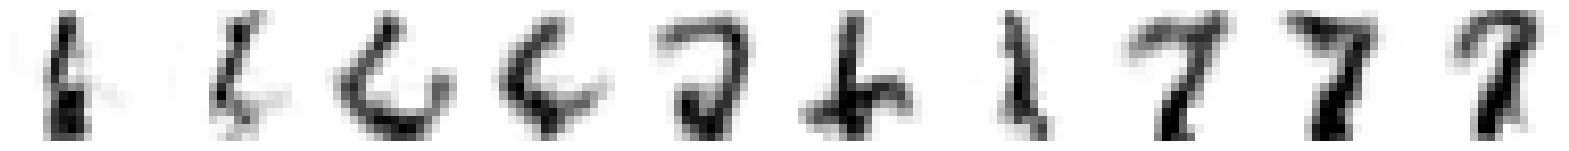

[Epoch 016] train: loss=-0.0002 reg=0.0001 cdiv=-0.0002 real=0.0029 fake=0.0027 | val: cdiv=-0.6403 real=0.0020 fake=-0.6383

Saved to ./output/generated_img_016.png


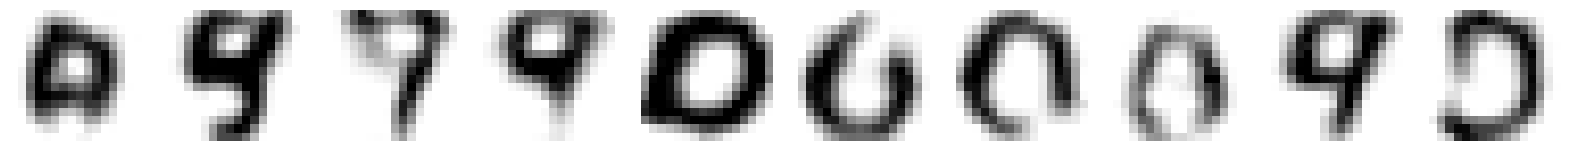

[Epoch 017] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0034 fake=0.0035 | val: cdiv=-0.6882 real=-0.0053 fake=-0.6934

Saved to ./output/generated_img_017.png


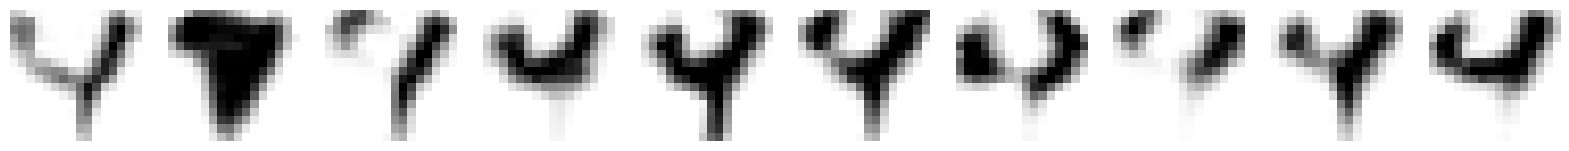

[Epoch 018] train: loss=0.0005 reg=0.0001 cdiv=0.0004 real=0.0003 fake=0.0007 | val: cdiv=-0.6827 real=0.0027 fake=-0.6800

Saved to ./output/generated_img_018.png


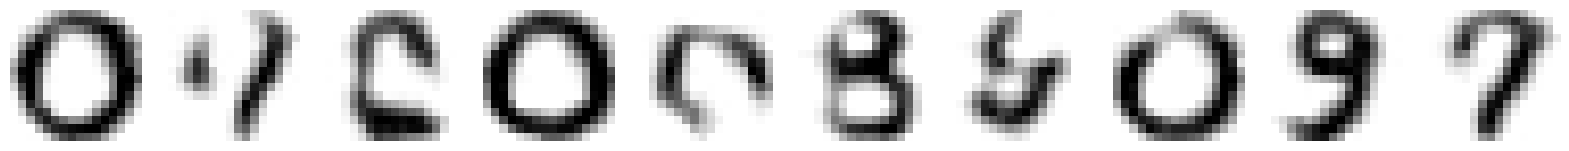

[Epoch 019] train: loss=-0.0003 reg=0.0001 cdiv=-0.0004 real=0.0021 fake=0.0017 | val: cdiv=-0.6983 real=0.0039 fake=-0.6944

Saved to ./output/generated_img_019.png


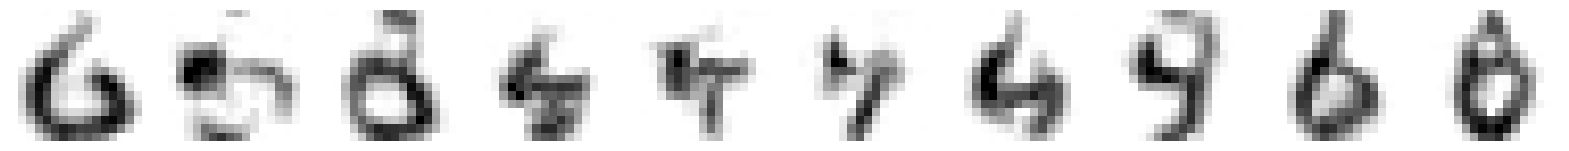

[Epoch 020] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0027 fake=0.0027 | val: cdiv=-0.7744 real=-0.0077 fake=-0.7821

Saved to ./output/generated_img_020.png


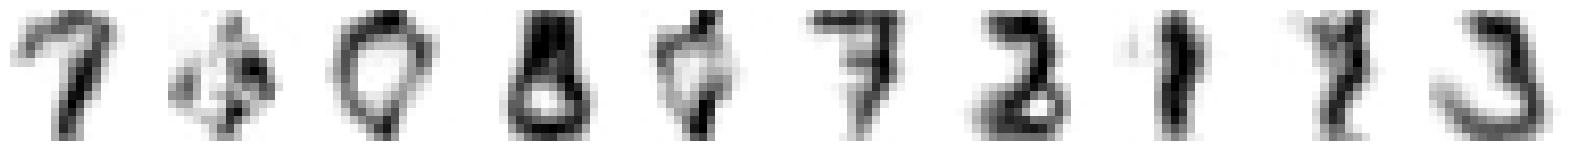

[Epoch 021] train: loss=-0.0001 reg=0.0001 cdiv=-0.0002 real=0.0003 fake=0.0001 | val: cdiv=-0.7945 real=0.0072 fake=-0.7873

Saved to ./output/generated_img_021.png


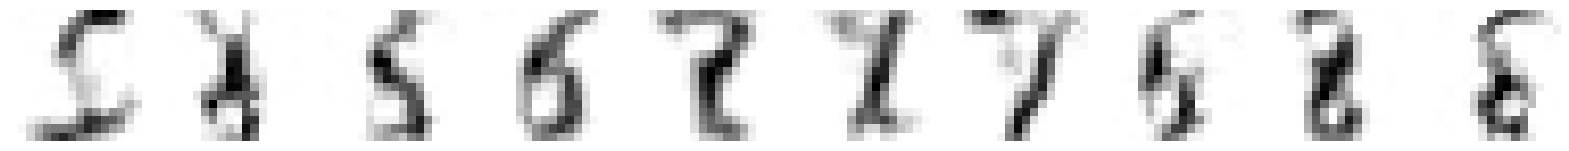

[Epoch 022] train: loss=0.0002 reg=0.0001 cdiv=0.0001 real=0.0027 fake=0.0027 | val: cdiv=-0.8461 real=-0.0162 fake=-0.8622

Saved to ./output/generated_img_022.png


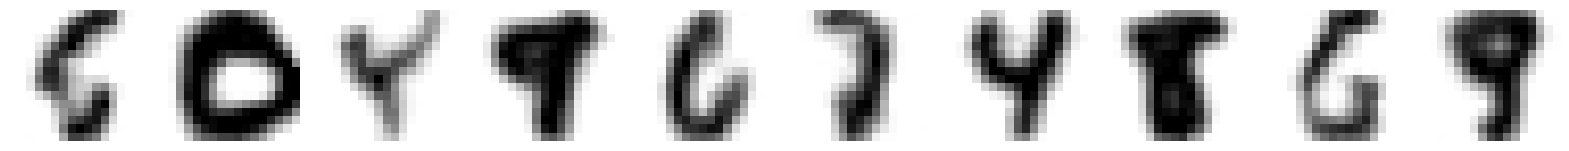

[Epoch 023] train: loss=0.0000 reg=0.0001 cdiv=-0.0000 real=-0.0004 fake=-0.0004 | val: cdiv=-0.8695 real=0.0061 fake=-0.8634

Saved to ./output/generated_img_023.png


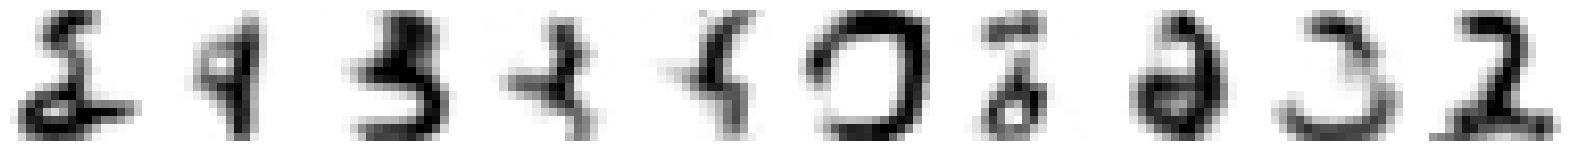

[Epoch 024] train: loss=0.0002 reg=0.0001 cdiv=0.0001 real=0.0016 fake=0.0017 | val: cdiv=-0.8667 real=-0.0132 fake=-0.8799

Saved to ./output/generated_img_024.png


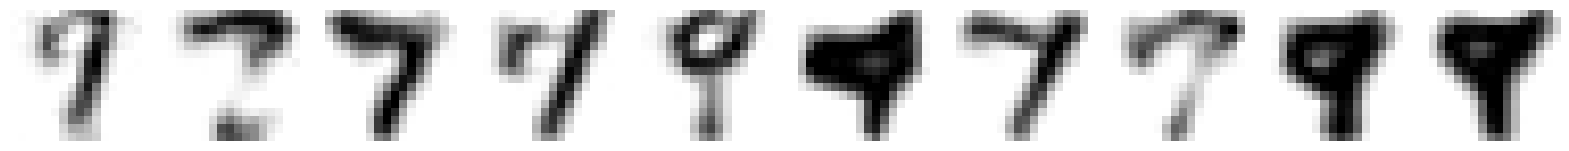

[Epoch 025] train: loss=-0.0002 reg=0.0001 cdiv=-0.0003 real=0.0007 fake=0.0004 | val: cdiv=-0.9117 real=0.0005 fake=-0.9112

Saved to ./output/generated_img_025.png


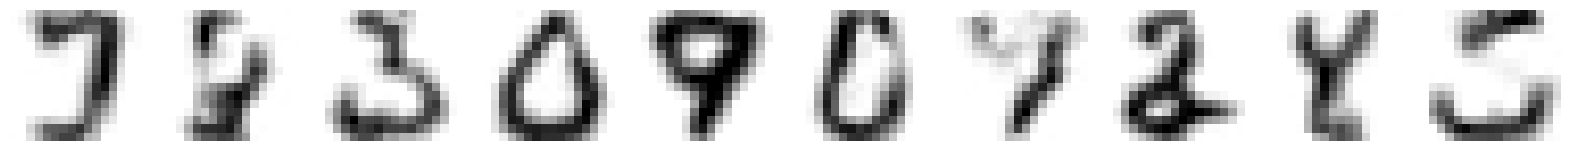

[Epoch 026] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0005 fake=0.0005 | val: cdiv=-0.8942 real=-0.0292 fake=-0.9233

Saved to ./output/generated_img_026.png


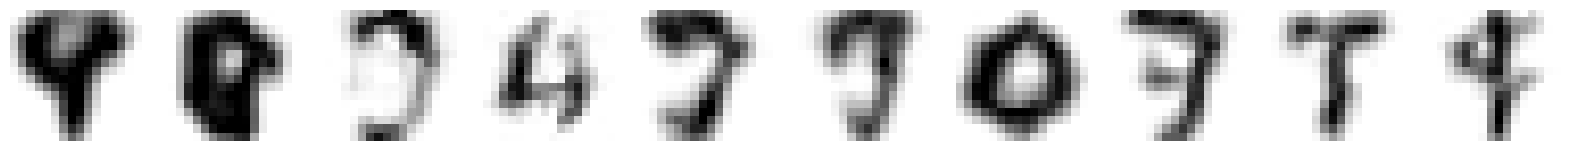

[Epoch 027] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0016 fake=0.0016 | val: cdiv=-0.9184 real=-0.0215 fake=-0.9399

Saved to ./output/generated_img_027.png


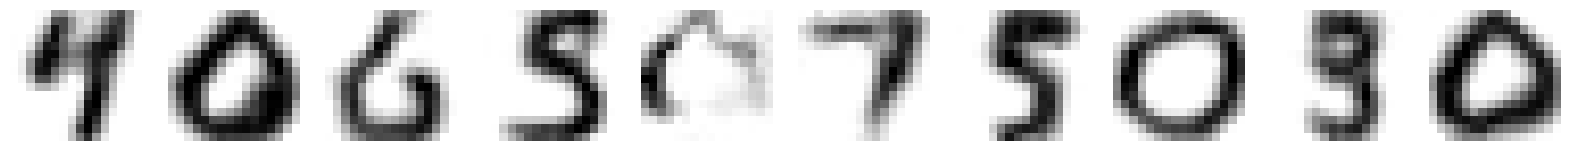

[Epoch 028] train: loss=-0.0004 reg=0.0001 cdiv=-0.0005 real=0.0014 fake=0.0009 | val: cdiv=-1.0377 real=-0.0032 fake=-1.0409

Saved to ./output/generated_img_028.png


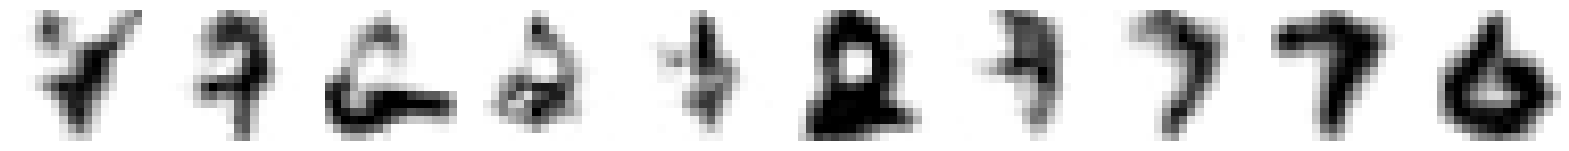

[Epoch 029] train: loss=0.0000 reg=0.0001 cdiv=-0.0001 real=0.0014 fake=0.0013 | val: cdiv=-1.0448 real=-0.0133 fake=-1.0581

Saved to ./output/generated_img_029.png


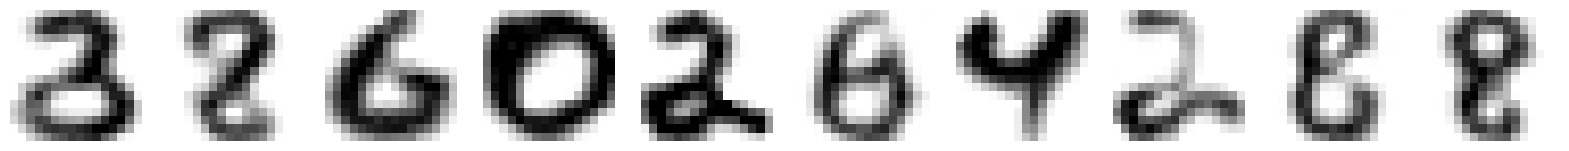

[Epoch 030] train: loss=-0.0002 reg=0.0001 cdiv=-0.0002 real=-0.0004 fake=-0.0006 | val: cdiv=-1.1193 real=-0.0072 fake=-1.1265

Saved to ./output/generated_img_030.png


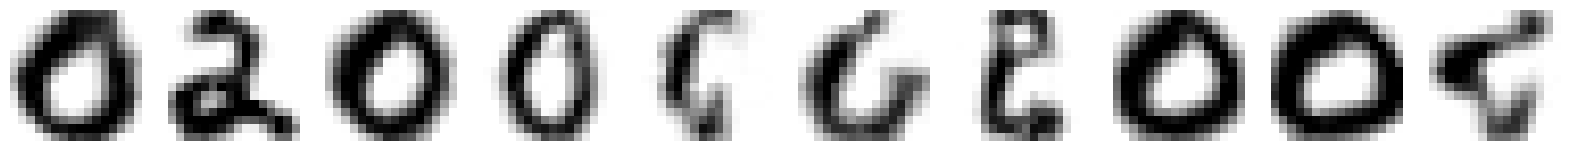

[Epoch 031] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0015 fake=0.0016 | val: cdiv=-1.1803 real=0.0001 fake=-1.1802

Saved to ./output/generated_img_031.png


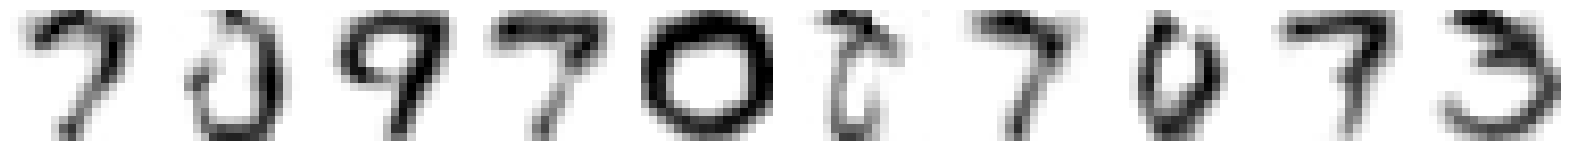

[Epoch 032] train: loss=0.0000 reg=0.0001 cdiv=-0.0000 real=0.0002 fake=0.0002 | val: cdiv=-1.1733 real=0.0082 fake=-1.1652

Saved to ./output/generated_img_032.png


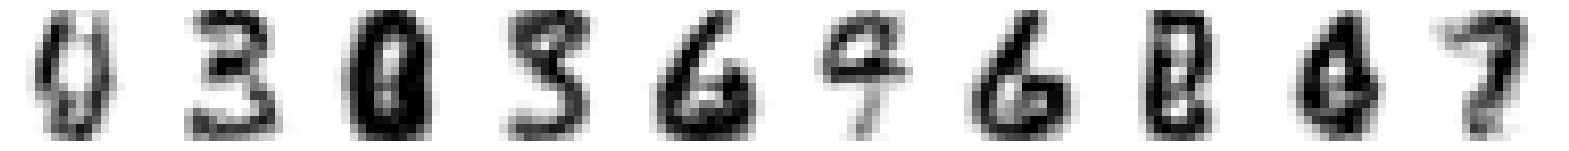

[Epoch 033] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0021 fake=0.0022 | val: cdiv=-1.2219 real=-0.0125 fake=-1.2345

Saved to ./output/generated_img_033.png


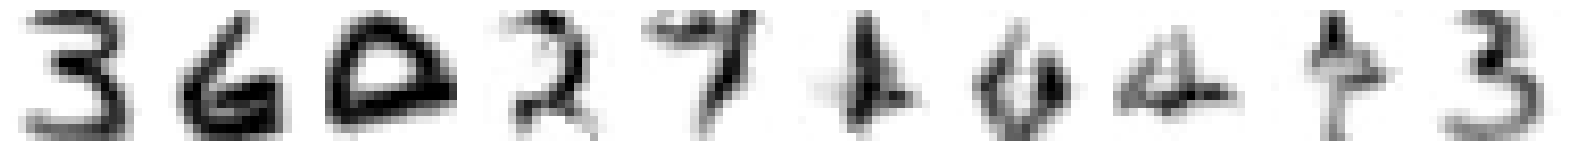

[Epoch 034] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=-0.0013 fake=-0.0013 | val: cdiv=-1.2458 real=-0.0001 fake=-1.2459

Saved to ./output/generated_img_034.png


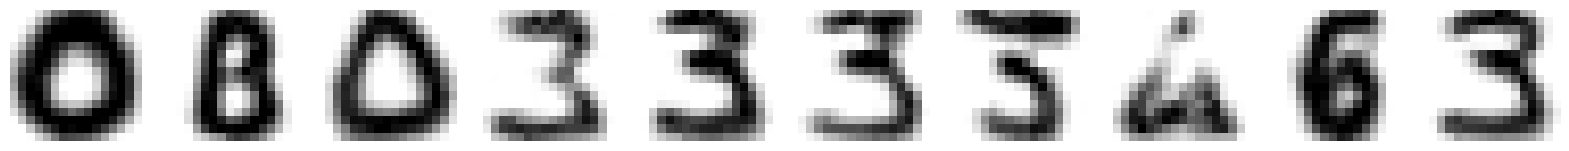

[Epoch 035] train: loss=0.0000 reg=0.0001 cdiv=-0.0000 real=0.0013 fake=0.0013 | val: cdiv=-1.3220 real=0.0034 fake=-1.3186

Saved to ./output/generated_img_035.png


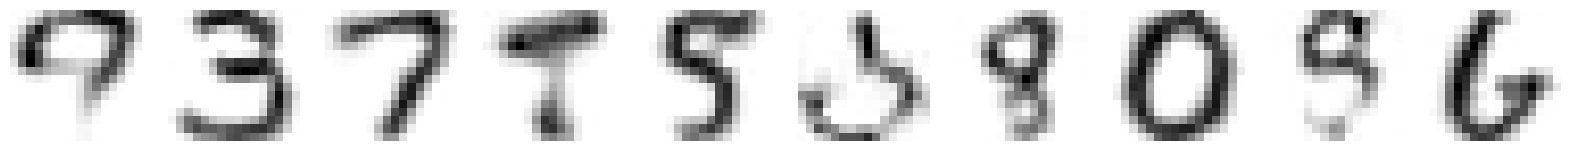

[Epoch 036] train: loss=0.0003 reg=0.0001 cdiv=0.0002 real=-0.0010 fake=-0.0008 | val: cdiv=-1.2672 real=0.0014 fake=-1.2658

Saved to ./output/generated_img_036.png


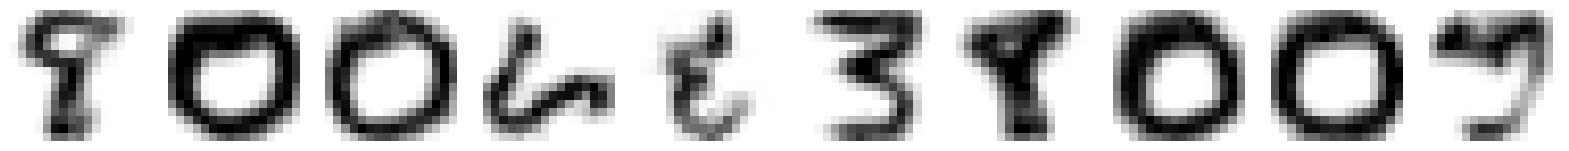

[Epoch 037] train: loss=-0.0003 reg=0.0001 cdiv=-0.0003 real=0.0034 fake=0.0030 | val: cdiv=-1.4230 real=0.0002 fake=-1.4229

Saved to ./output/generated_img_037.png


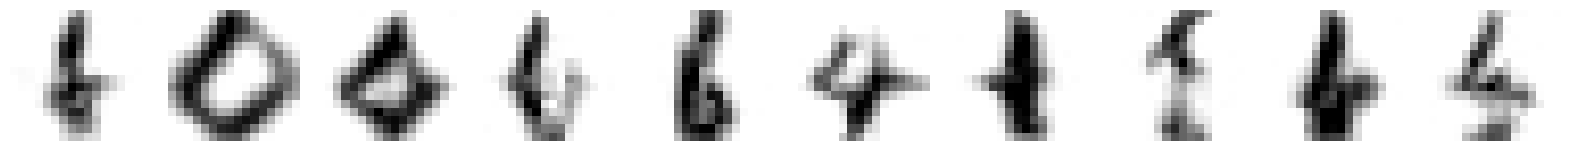

[Epoch 038] train: loss=0.0005 reg=0.0001 cdiv=0.0004 real=-0.0001 fake=0.0003 | val: cdiv=-1.3797 real=-0.0137 fake=-1.3933

Saved to ./output/generated_img_038.png


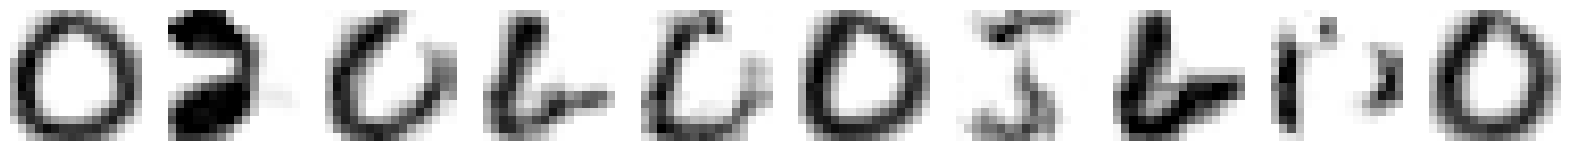

[Epoch 039] train: loss=-0.0001 reg=0.0001 cdiv=-0.0002 real=-0.0008 fake=-0.0010 | val: cdiv=-1.5175 real=-0.0139 fake=-1.5313

Saved to ./output/generated_img_039.png


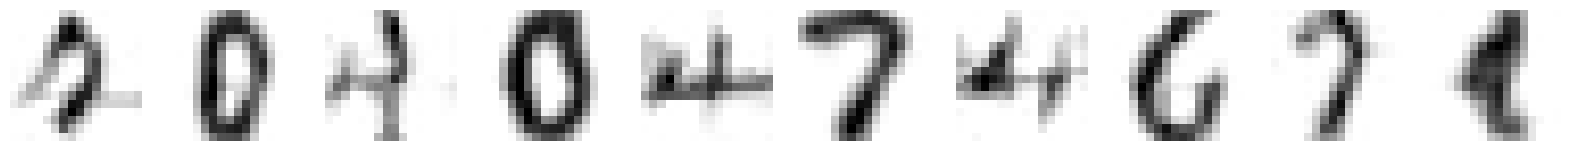

[Epoch 040] train: loss=0.0001 reg=0.0001 cdiv=-0.0000 real=0.0024 fake=0.0024 | val: cdiv=-1.4873 real=0.0011 fake=-1.4862

Saved to ./output/generated_img_040.png


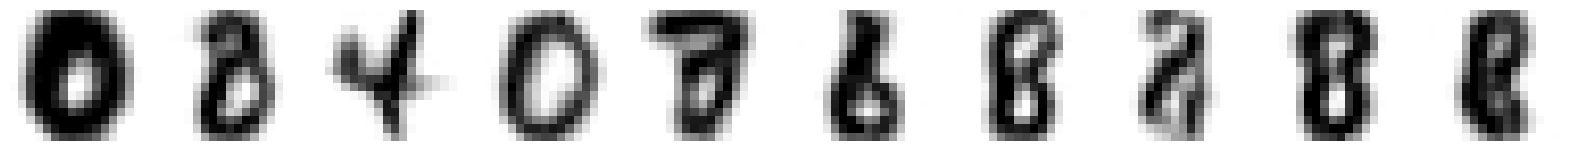

[Epoch 041] train: loss=0.0000 reg=0.0001 cdiv=-0.0001 real=0.0001 fake=-0.0000 | val: cdiv=-1.5548 real=-0.0017 fake=-1.5565

Saved to ./output/generated_img_041.png


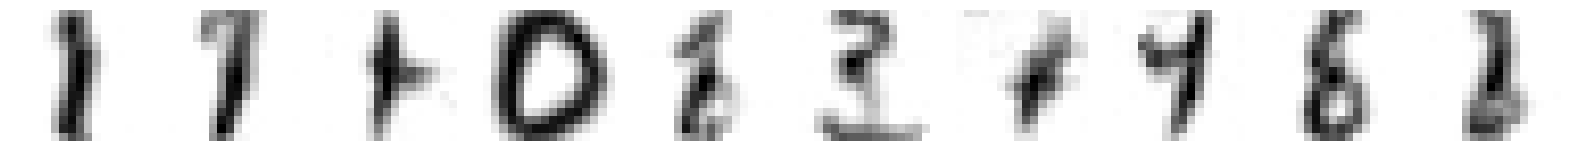

[Epoch 042] train: loss=0.0004 reg=0.0001 cdiv=0.0003 real=-0.0015 fake=-0.0012 | val: cdiv=-1.5818 real=-0.0023 fake=-1.5841

Saved to ./output/generated_img_042.png


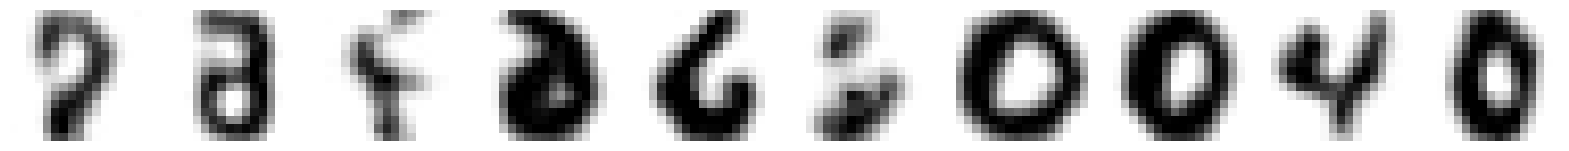

[Epoch 043] train: loss=-0.0002 reg=0.0001 cdiv=-0.0003 real=0.0012 fake=0.0009 | val: cdiv=-1.5945 real=-0.0069 fake=-1.6015

Saved to ./output/generated_img_043.png


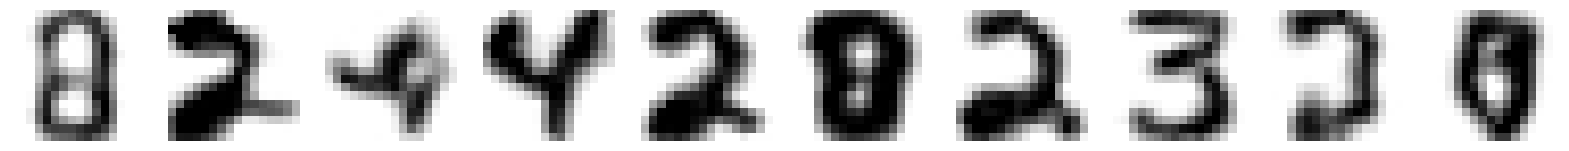

[Epoch 044] train: loss=-0.0003 reg=0.0001 cdiv=-0.0004 real=0.0024 fake=0.0020 | val: cdiv=-1.7569 real=0.0180 fake=-1.7389

Saved to ./output/generated_img_044.png


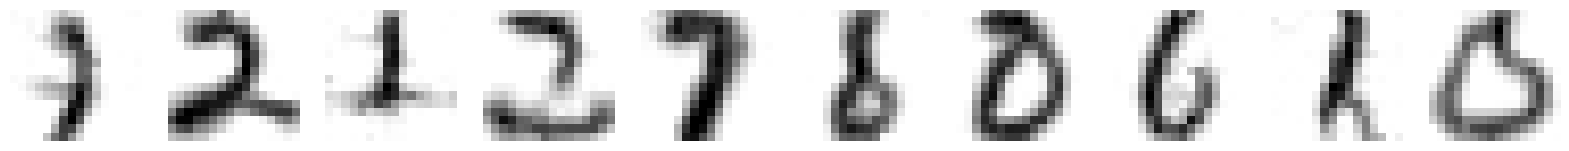

[Epoch 045] train: loss=-0.0003 reg=0.0001 cdiv=-0.0004 real=-0.0004 fake=-0.0008 | val: cdiv=-1.8543 real=-0.0150 fake=-1.8693

Saved to ./output/generated_img_045.png


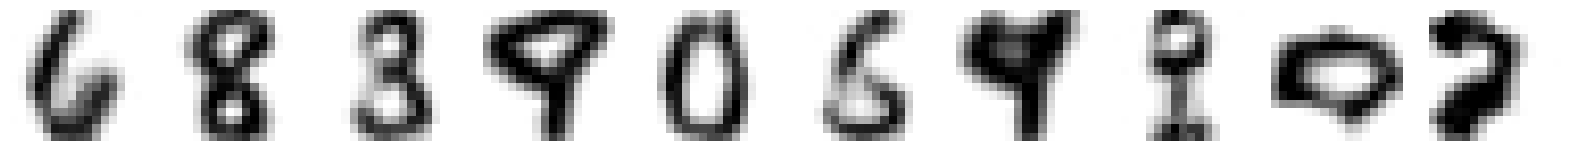

[Epoch 046] train: loss=0.0002 reg=0.0001 cdiv=0.0001 real=0.0007 fake=0.0009 | val: cdiv=-1.8573 real=-0.0069 fake=-1.8642

Saved to ./output/generated_img_046.png


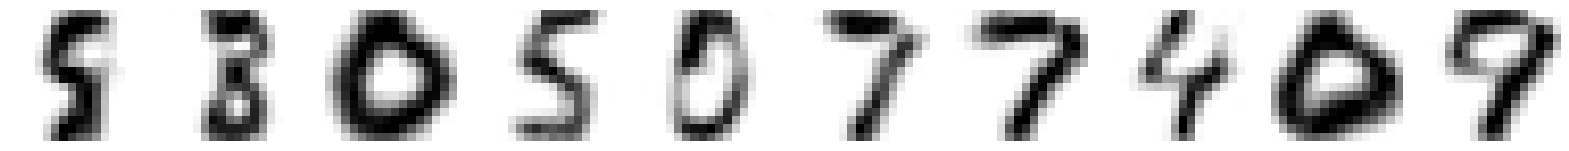

[Epoch 047] train: loss=0.0003 reg=0.0001 cdiv=0.0003 real=-0.0013 fake=-0.0011 | val: cdiv=-1.8395 real=0.0175 fake=-1.8220

Saved to ./output/generated_img_047.png


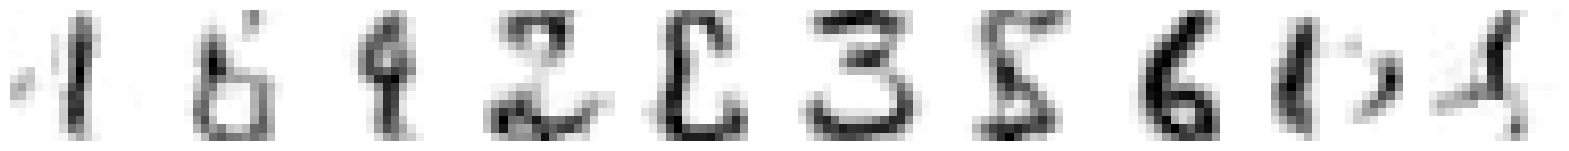

[Epoch 048] train: loss=0.0003 reg=0.0001 cdiv=0.0002 real=0.0009 fake=0.0011 | val: cdiv=-1.7498 real=-0.0031 fake=-1.7529

Saved to ./output/generated_img_048.png


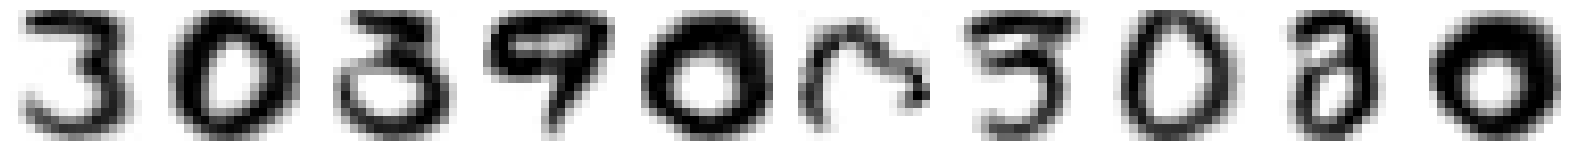

[Epoch 049] train: loss=0.0001 reg=0.0000 cdiv=0.0001 real=0.0004 fake=0.0005 | val: cdiv=-1.8549 real=-0.0127 fake=-1.8676

Saved to ./output/generated_img_049.png


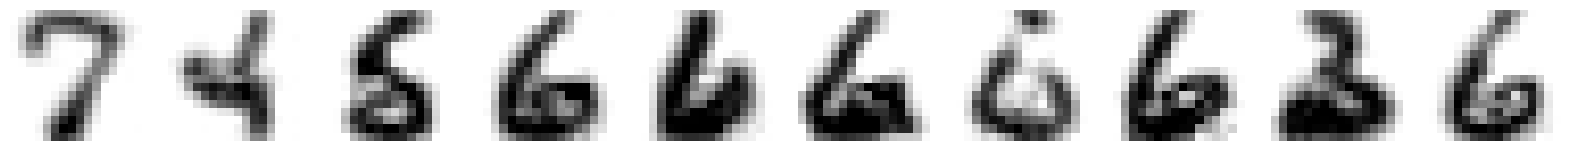

[Epoch 050] train: loss=0.0002 reg=0.0001 cdiv=0.0001 real=-0.0016 fake=-0.0015 | val: cdiv=-2.0191 real=0.0073 fake=-2.0117

Saved to ./output/generated_img_050.png


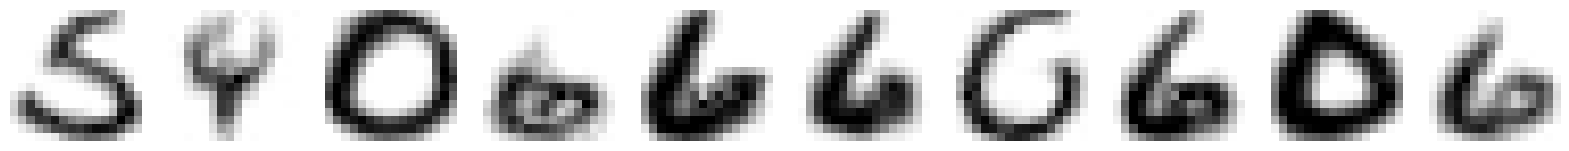

[Epoch 051] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0021 fake=0.0021 | val: cdiv=-2.0210 real=0.0014 fake=-2.0196

Saved to ./output/generated_img_051.png


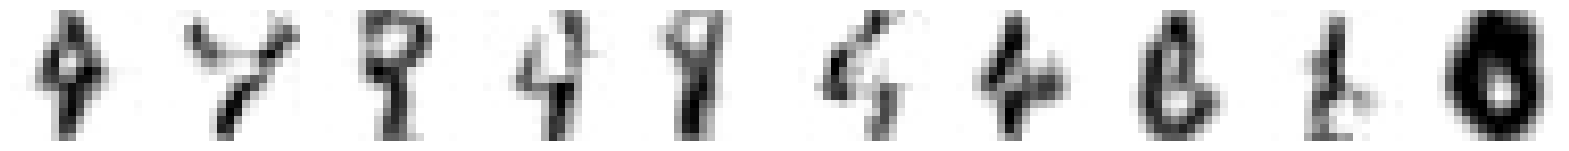

[Epoch 052] train: loss=0.0002 reg=0.0001 cdiv=0.0001 real=0.0004 fake=0.0005 | val: cdiv=-2.0124 real=-0.0186 fake=-2.0310

Saved to ./output/generated_img_052.png


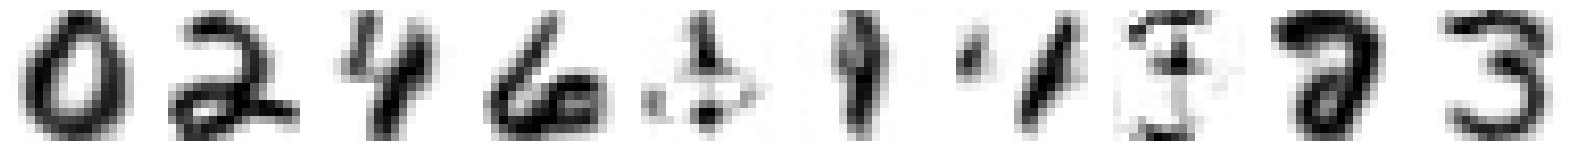

[Epoch 053] train: loss=-0.0003 reg=0.0001 cdiv=-0.0004 real=-0.0004 fake=-0.0008 | val: cdiv=-2.0564 real=-0.0011 fake=-2.0575

Saved to ./output/generated_img_053.png


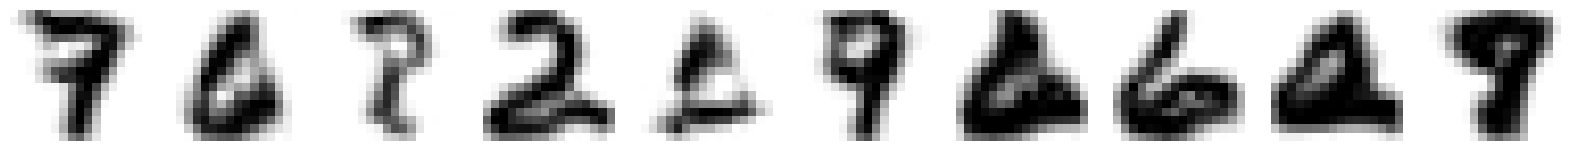

[Epoch 054] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0007 fake=0.0007 | val: cdiv=-2.2314 real=-0.0107 fake=-2.2421

Saved to ./output/generated_img_054.png


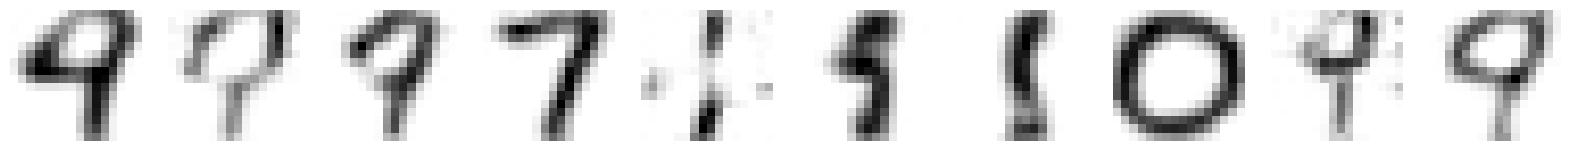

[Epoch 055] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=-0.0012 fake=-0.0011 | val: cdiv=-2.2338 real=0.0048 fake=-2.2290

Saved to ./output/generated_img_055.png


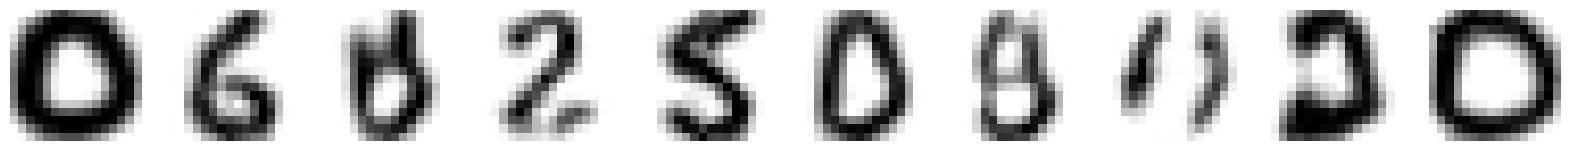

[Epoch 056] train: loss=-0.0000 reg=0.0001 cdiv=-0.0001 real=0.0019 fake=0.0019 | val: cdiv=-2.3301 real=0.0059 fake=-2.3242

Saved to ./output/generated_img_056.png


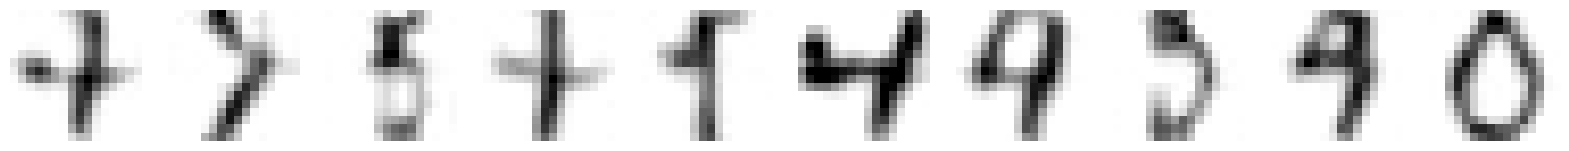

[Epoch 057] train: loss=0.0001 reg=0.0001 cdiv=0.0000 real=0.0000 fake=0.0000 | val: cdiv=-2.3686 real=0.0275 fake=-2.3412

Saved to ./output/generated_img_057.png


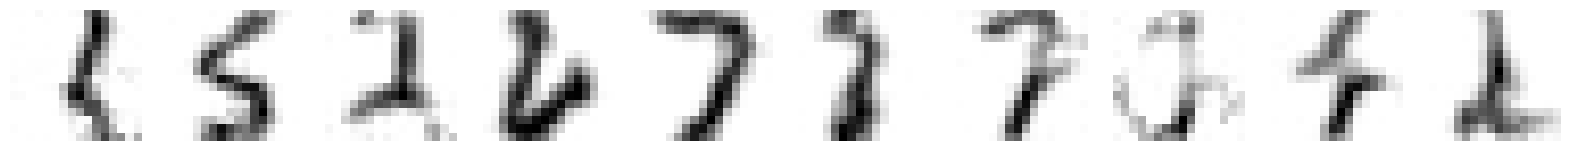

[Epoch 058] train: loss=-0.0005 reg=0.0001 cdiv=-0.0006 real=0.0006 fake=0.0000 | val: cdiv=-2.5022 real=0.0103 fake=-2.4919

Saved to ./output/generated_img_058.png


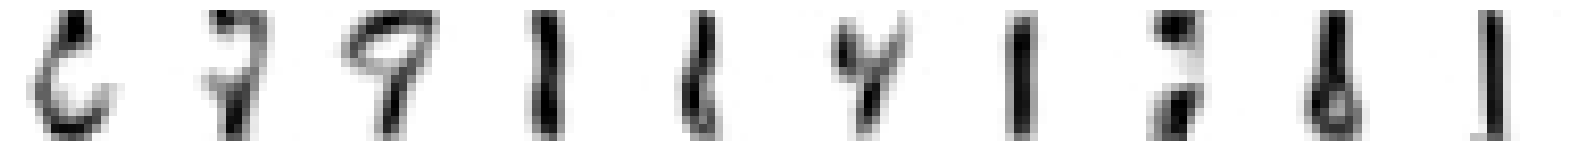

[Epoch 059] train: loss=0.0003 reg=0.0001 cdiv=0.0002 real=-0.0008 fake=-0.0006 | val: cdiv=-2.4505 real=-0.0105 fake=-2.4610

Saved to ./output/generated_img_059.png


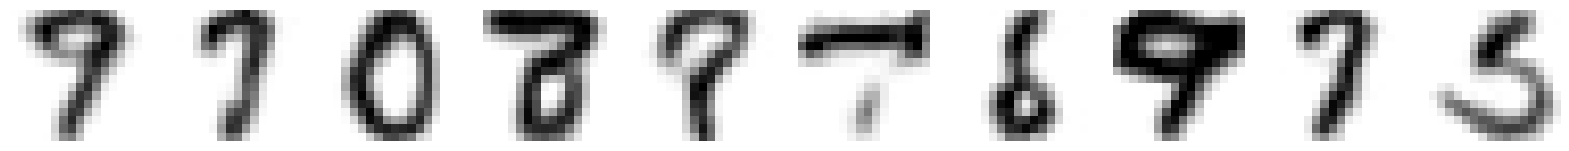

[Epoch 060] train: loss=0.0002 reg=0.0001 cdiv=0.0001 real=-0.0010 fake=-0.0009 | val: cdiv=-2.3991 real=-0.0042 fake=-2.4034

Saved to ./output/generated_img_060.png


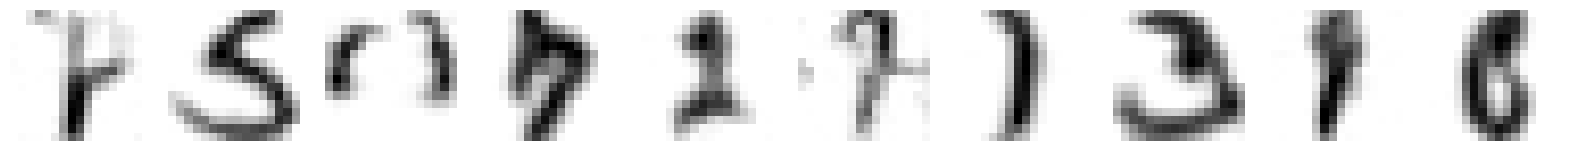

In [21]:
image_generator_callback = ImageGenerator(ebm, num_img=10)                      # callback p/ gerar e salvar imagens ao fim de cada época

# === Loop de treinamento ===
for epoch in range(1, EPOCHS + 1):                                              # laço de épocas [1..EPOCHS]
    ebm.model.train()                                                           # modo de treinamento (ativa camadas específicas se houver)
    train_logs = {"loss": [], "reg": [], "cdiv": [], "real": [], "fake": []}    # buffers p/ médias por época

    # ========= TREINAMENTO =========
    for batch in train_dl:                                                      # itera mini-lotes do treino
        real_imgs = batch[0]                                                    # (imagens, rótulos) -> seleciona apenas imagens (B,C,H,W)
        logs = ebm.train_step(real_imgs)                                        # 1 passo de treino (CD + reg) -> dict de métricas
        for k in train_logs:                                                    # acumula métricas do batch
            train_logs[k].append(logs[k])

    train_avg = {k: float(np.mean(v)) for k, v in train_logs.items()}           # médias por época (train)

    # ========= VALIDAÇÃO =========
    ebm.model.eval()                                                            # modo avaliação (desliga dropout/bn-update)
    val_logs = {"cdiv": [], "real": [], "fake": []}                             # buffers p/ métricas de validação
    with torch.no_grad():                                                       # sem gradiente na validação
        for batch in test_dl:                                                   # itera mini-lotes do teste
            real_imgs = batch[0]                                                # (imagens, rótulos) -> pega apenas imagens
            logs = ebm.test_step(real_imgs)                                     # passo de validação (contraste simples)
            for k in val_logs:
                val_logs[k].append(logs[k])

    val_avg = {k: float(np.mean(v)) for k, v in val_logs.items()}               # médias por época (val)

    # ========= LOGGING =========
    print(f"[Epoch {epoch:03d}] "                                               # imprime resumo legível da época
          f"train: loss={train_avg['loss']:.4f} reg={train_avg['reg']:.4f} "
          f"cdiv={train_avg['cdiv']:.4f} real={train_avg['real']:.4f} fake={train_avg['fake']:.4f} | "
          f"val: cdiv={val_avg['cdiv']:.4f} real={val_avg['real']:.4f} fake={val_avg['fake']:.4f}")

    # ========= CALLBACKS (estilo Keras) =========
    image_generator_callback.on_epoch_end(epoch)                                # gera e salva imagens geradas por época

# Amostragem

In [22]:
start_imgs = 2 * torch.rand(10, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) - 1  # uniforme [0,1] -> [-1,1] (BCHW)

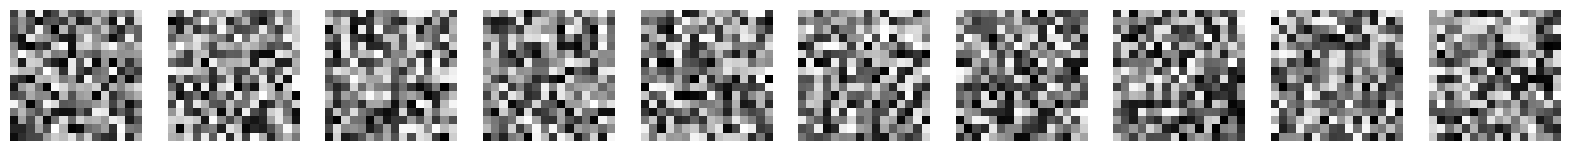

In [23]:
display(start_imgs)

In [24]:
gen_img = generate_samples(          # roda dinâmica de Langevin
    ebm.model,                       # modelo EBM (rede MLP)
    start_imgs,                      # imagens iniciais (ruído uniforme [-1,1])
    steps=1000,                      # número de passos de Langevin
    step_size=STEP_SIZE,             # intensidade de atualização
    noise=NOISE,                     # std do ruído gaussiano por passo
    return_img_per_step=True,        # retorna trajetória (todas as etapas)
)

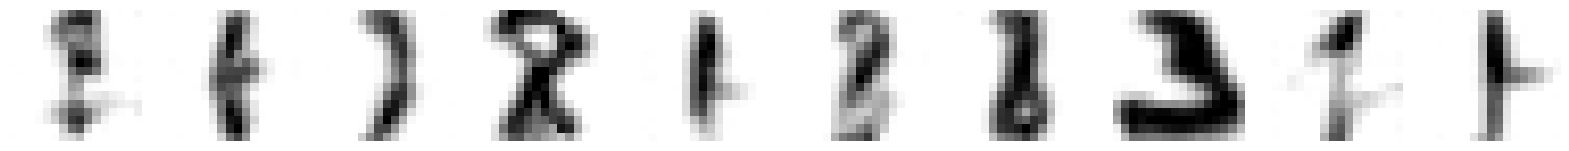

In [25]:
display(gen_img[-1].detach().cpu())   # pega última imagem gerada, move p/ CPU e plota

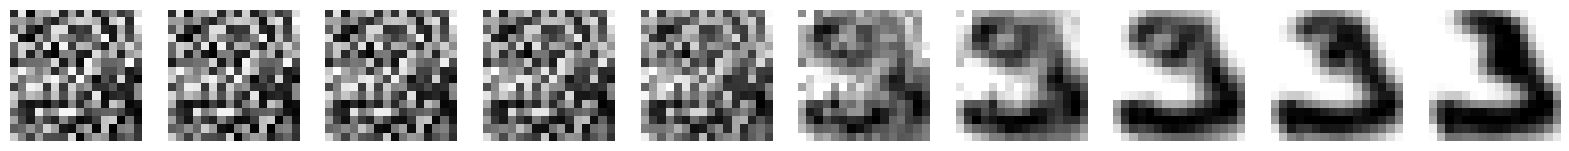

In [29]:
imgs = []                                                                   # lista p/ armazenar imagens ao longo dos passos (T selecionados)
for i in [0, 1, 3, 5, 10, 30, 50, 100, 300, 999]:                           # passos específicos da cadeia de Langevin
    # gen_img: shape (T, B, C, H, W)
    # gen_img[i] -> imagens no passo i    -> (B, C, H, W)
    # gen_img[i][6] -> imagem de índice 6 -> (C, H, W)
    imgs.append(gen_img[i][7].detach().cpu().numpy())                       # extrai sempre a mesma amostra (6) para ver sua evolução

imgs = torch.tensor(np.array(imgs))                                         # empilha lista -> tensor (n_passos, C, H, W)
display(imgs)                                                               # exibe a trajetória visual da amostra ao longo dos passos


# Tarefa
- Implemente um modelo baseado em energia utilizando uma rede convolucional.
- Realize o treinamento com o conjunto de dados USPS.
- Reporte as imagens sintéticas geradas.
- Reporte o influência do número de passos do processo de Langevin na geração das amostras.
- Reporte o desempenho do modelo treinado utilizando precisão e revocação de variedades (Lab 6).

# Classificador

## Modelo

In [39]:
# Classificador dividido em dois nn.Sequential: feature_extractor + classifier_head

# Extrator de features
feature_extractor = nn.Sequential(
    nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),    # -> (B,32,8,8)
    nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # -> (B,64,4,4)
    nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),                   # -> (B,128,4,4)
    nn.AdaptiveAvgPool2d(1),                            # -> (B,128,1,1)
    nn.Flatten()                                        # -> (B,128)
).to(DEVICE)

# Cabeça classificadora
classifier_head = nn.Sequential(
    nn.Linear(128, 10)                                  # -> (B,10)
).to(DEVICE)

# Modelo completo
full_model = nn.Sequential(
    feature_extractor,
    classifier_head
).to(DEVICE)

In [40]:
# Extrator de features
summary(feature_extractor, input_size=(1, 1, 16, 16))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 128]                  --
├─Conv2d: 1-1                            [1, 32, 16, 16]           320
├─ReLU: 1-2                              [1, 32, 16, 16]           --
├─MaxPool2d: 1-3                         [1, 32, 8, 8]             --
├─Conv2d: 1-4                            [1, 64, 8, 8]             18,496
├─ReLU: 1-5                              [1, 64, 8, 8]             --
├─MaxPool2d: 1-6                         [1, 64, 4, 4]             --
├─Conv2d: 1-7                            [1, 128, 4, 4]            73,856
├─ReLU: 1-8                              [1, 128, 4, 4]            --
├─AdaptiveAvgPool2d: 1-9                 [1, 128, 1, 1]            --
├─Flatten: 1-10                          [1, 128]                  --
Total params: 92,672
Trainable params: 92,672
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.45
Input size (MB): 0.00
Forward/backwa

In [33]:
# Cabeça classificadora
summary(classifier_head, input_size=(1, 128))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 10]                   --
├─Linear: 1-1                            [1, 10]                   1,290
Total params: 1,290
Trainable params: 1,290
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01

## Treinamento do classificador

In [34]:
## Função de perda e otimizadores
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(full_model.parameters(), lr=1e-3)


In [41]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()                                               # Coloca o modelo em modo de treinamento (ativa dropout, batchnorm, etc.)
    total_loss, total, correct = 0.0, 0, 0                      # Inicializa acumuladores de perda, número de exemplos e acertos
    for x, y in dataloader:                                     # Itera pelos lotes de dados
        x, y = x.to(DEVICE), y.to(DEVICE)                       # Move entradas e rótulos para o dispositivo (CPU/GPU)
        logits = model(x)                                       # Calcula as predições do modelo
        loss = loss_fn(logits, y)                               # Calcula a perda entre predições e rótulos
        optimizer.zero_grad()                                   # Zera gradientes acumulados
        loss.backward()                                         # Calcula gradientes via backpropagation
        optimizer.step()                                        # Atualiza os parâmetros do modelo
        total_loss += loss.item()                               # Acumula a perda do lote
        correct    += (logits.argmax(1) == y).sum().item()      # Conta acertos comparando previsão com rótulo
        total      += x.size(0)                                 # Conta número de exemplos processados
    return total_loss/total, correct/total                      # Retorna perda média por exemplo e acurácia

In [42]:
@torch.no_grad()                                                 # Desativa o cálculo de gradientes (avaliação mais rápida e com menor uso de memória)
def evaluate(dataloader, model, loss_fn):
    model.eval()                                                 # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm usa estatísticas fixas)
    total_loss, total, correct = 0.0, 0, 0                       # Inicializa acumuladores de perda, número de exemplos e acertos
    for x, y in dataloader:                                      # Itera pelos lotes de dados
        x, y = x.to(DEVICE), y.to(DEVICE)                        # Move entradas e rótulos para o dispositivo (CPU/GPU)
        logits = model(x)                                        # Calcula as predições do modelo
        loss = loss_fn(logits, y)                                # Calcula a perda entre predições e rótulos
        total_loss += loss.item()                                # Acumula a perda do lote
        correct    += (logits.argmax(1) == y).sum().item()       # Conta acertos comparando previsão com rótulo
        total      += x.size(0)                                  # Conta número de exemplos processados
    return total_loss/total, correct/total                       # Retorna perda média por exemplo e acurácia

In [43]:
n_epocas = 10                                                                                       # Define o número total de épocas de treinamento
for ep in range(n_epocas):                                                                          # Loop principal sobre as épocas
    tr_loss, tr_acc = train_one_epoch(train_dl, full_model, loss_fn, optimizer)                     # Executa uma época de treinamento e retorna perda/acurácia
    te_loss, te_acc = evaluate(test_dl, full_model, loss_fn)                                        # Avalia o modelo no conjunto de teste e retorna perda/acurácia
    print(f"Época {ep + 1}/{n_epocas} | Treinamento: perda={tr_loss:.4f} acc={tr_acc:.3f} | "
          f"Teste: perda={te_loss:.4f} acc={te_acc:.3f}")                                          # Imprime resultados formatados de treino e teste


Época 1/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 2/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 3/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 4/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 5/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 6/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 7/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 8/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 9/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087
Época 10/10 | Treinamento: perda=2.3023 acc=0.080 | Teste: perda=2.3014 acc=0.087


In [44]:
torch.save(feature_extractor.state_dict(), 'feature_extractor.pth')

## Extração de características

In [45]:
def create_noise(batch_size, z_size, mode_z):               # Define a função create_noise para gerar vetores de ruído aleatório.
    if mode_z == 'uniform':                                 # Caso o modo de geração seja "uniform":
        input_z = torch.rand(batch_size, z_size)*2 - 1      # Gera amostras de ruído com distribuição uniforme em [-1, 1].
    elif mode_z == 'normal':                                # Caso o modo de geração seja "normal":
        input_z = torch.randn(batch_size, z_size)           # Gera amostras de ruído com distribuição normal padrão N(0,1).
    return input_z                                          # Retorna o lote de vetores de ruído gerados (tensor de shape [batch_size, z_size]).

In [46]:
image_size = (28, 28)        # Define o tamanho da imagem de saída (MNIST possui imagens de 28x28 pixels).
z_size = 100                  # Define o tamanho do vetor de ruído (dimensão do espaço latente usado pelo gerador).
batch_size = 64                # Define o tamanho do lote de imagens a serem geradas.
mode_z = 'uniform'  
torch.manual_seed(1)         # Fixa a semente para reprodutibilidade dos resultados gerados pelo PyTorch.

In [47]:
from torch.utils.data import Subset
@torch.no_grad()                                                                                   # Desativa cálculo de gradientes (inferencia mais rápida e leve)
def get_features(dataset, feature_extractor, N: int, batch_size: int = 512) -> np.ndarray:
    feature_extractor.eval()                                                                        # Coloca o extrator de características em modo de avaliação
    N_eff = min(N, len(dataset))                                                                    # Garante que N não ultrapasse o tamanho do dataset
    subset = Subset(dataset, range(N_eff))                                                          # Seleciona os primeiros N exemplos do dataset
    loader = DataLoader(subset, batch_size=batch_size, shuffle=False, drop_last=False)              # Cria um DataLoader sem embaralhar e sem descartar amostras

    feats_list = []                                                                                 # Lista para acumular os vetores de características
    for x, _ in loader:                                                                             # Itera sobre os lotes do DataLoader
        x = x.to(DEVICE)                                                                            # Move o batch de imagens para o dispositivo (CPU/GPU)
        emb = feature_extractor(x)                                                                  # Extrai features com o modelo
        feats_list.append(emb.detach().cpu().numpy().astype(np.float32))                            # Converte para NumPy float32 e adiciona à lista
    return np.concatenate(feats_list, axis=0)                                                       # Concatena todos os lotes em um único array (N, D)

In [59]:
def sample_new_examples(batch_size, steps, step_size, noise, model, examples):                                   # gera b amostras refinadas
    b = batch_size                                                                                    # alias do tamanho desejado (B)

    n_new = np.random.binomial(b, 0.05)                                                               # ~5% amostras novas p/ diversidade

    # gera n_new imagens novas aleatórias ∈ [-1,1], shape: (n_new,C,H,W)
    rand_imgs = torch.rand(n_new, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) * 2 - 1

    # escolhe (b - n_new) exemplos do buffer (reuso de amostras antigas)
    old_imgs = torch.cat(                                                                             # concatena lista de tensores
        random.choices(examples, k=b - n_new), dim=0                                             # escolhe com reposição
    ) if (b - n_new) > 0 else torch.empty(0, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE)

    # concatena novas + antigas -> shape final: (b,C,H,W)
    inp_imgs = torch.cat([rand_imgs, old_imgs], dim=0)

    # Dinâmica de Langevin para mover as imagens em direção a regiões de alta probabilidade
    inp_imgs = generate_samples(model, inp_imgs, steps=steps, step_size=step_size, noise=noise)  # output shape: (b,C,H,W)

    # adiciona as novas amostras refinadas ao início do buffer
    # unsqueeze(0) → garante shape consistente (1,C,H,W) por item
    examples = [t.unsqueeze(0) for t in inp_imgs] + examples

    # mantém o tamanho do buffer limitado
    examples = examples[:BUFFER_SIZE]

    return inp_imgs          


def get_features_from_generator(
    gen_model,
    feature_extractor,
    N: int,
    *,
    z_dim: int = z_size,
    mode_z: str = mode_z,
    batch: int = batch_size
) -> np.ndarray:

    gen_model.eval()                                                                                # Coloca o gerador em modo de avaliação
    feature_extractor.eval()                                                                        # Coloca o extrator em modo de avaliação

    feats = []                                                                                      # Lista para acumular as features
    remaining = N                                                                                   # Número de amostras restantes a serem geradas

    while remaining > 0:                                                                            # Gera em lotes até completar N
        cur = min(batch, remaining)                                                                 # Define o tamanho do lote atual
        #z = create_noise(cur, z_dim, mode_z).to(DEVICE)                                             # Gera ruído latente (cur, z_dim) e move para o dispositivo

        #imgs = gen_model(z).view(cur, 1, *image_size).to(DEVICE)                                    # Gera imagens (cur, 1, 28, 28) no intervalo [-1,1]
        examples = [
            (torch.rand(1, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) * 2 - 1)    # (1,C,H,W) amostra aleatória
            for _ in range(BATCH_SIZE)
        ]

        imgs = sample_new_examples(                 # gera exatamente B amostras negativas
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE,           # Langevin curto
            batch_size=cur, model=gen_model, examples = examples
        )  

        emb  = feature_extractor(imgs)                                                              # Extrai as features das imagens geradas
        feats.append(emb.detach().cpu().numpy().astype(np.float32))                                 # Converte para NumPy float32 e acumula
        remaining -= cur                                                                            # Atualiza o contador de amostras restantes
    return np.concatenate(feats, axis=0)                                                            # Concatena todos as features em um array (N, D)

## Precisão e Revocação de Variedades

In [60]:
feature_extractor.load_state_dict(torch.load('models/feature_extractor.pth', map_location=DEVICE))

<All keys matched successfully>

In [61]:
dataset = test_ds                                                                  # Usa o conjunto de teste USPS
#feature_extractor = full_model[0]                                                     # Seleciona apenas a parte extratora de características do classificador
N = 10_000                                                                            # Número de amostras a serem processadas
batch_size = 512                                                                      # Tamanho do mini-lote

### Features reais

In [62]:
real_features = get_features(                                                         # Extrai as features das N primeiras imagens do dataset
    dataset=dataset,
    feature_extractor=feature_extractor,
    N=N,
    batch_size=batch_size
)
print("real_features shape:", real_features.shape)                                    # Mostra o shape esperado: (N, dimensão do embedding), ex.: (10000, 128)


real_features shape: (2007, 128)


### Features geradas

In [63]:
torch.save(model.state_dict(), 'energy.pth')

In [64]:
gen_model = model

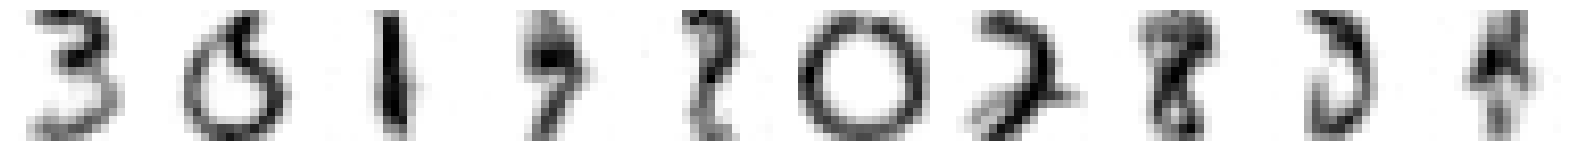

In [78]:
n_new = np.random.binomial(1, 0.05)                                                               # ~5% amostras novas p/ diversidade
rand_imgs = torch.rand(10, CHANNELS, IMAGE_SIZE, IMAGE_SIZE, device=DEVICE) * 2 - 1
gen_img = generate_samples(          # roda dinâmica de Langevin
    gen_model,                       # modelo EBM (rede MLP)
    rand_imgs,                      # imagens iniciais (ruído uniforme [-1,1])
    steps=1000,                      # número de passos de Langevin
    step_size=STEP_SIZE,             # intensidade de atualização
    noise=NOISE,                     # std do ruído gaussiano por passo
    return_img_per_step=True,        # retorna trajetória (todas as etapas)
)
display(gen_img[-1].detach().cpu())   # pega última imagem gerada, move p/ CPU e plota

In [79]:
fake_features = get_features_from_generator(                                          # Extrai as features das imagens geradas pelo gerador
    gen_model,                                                                        # Modelo gerador previamente treinado
    feature_extractor=feature_extractor,                                              # Extrator de características do classificador
    N=N,                                                                              # Número de imagens a serem geradas e processadas
    z_dim=z_size,                                                                     # Dimensão do vetor de ruído de entrada do gerador
    mode_z=mode_z,                                                                    # Distribuição do ruído (uniforme ou normal)
    batch=batch_size                                                                  # Tamanho do mini-lote para geração e extração
)
print("fake_features shape:", fake_features.shape)                                    # Mostra o shape esperado: (N, dimensão do embedding), ex.: (10000, 128)

fake_features shape: (10000, 128)


### Cálculo

In [80]:
from prdc import compute_prdc
metrics = compute_prdc(real_features, fake_features, nearest_k=5)                     # Calcula métricas de Precisão e Revocação de Variedades (PRDC)
print(f"Precisão: {metrics['precision']:.4f}")                                        # Exibe a precisão
print(f"Revocação: {metrics['recall']:.4f}")                                          # Exibe a revocação

Num real: 2007 Num fake: 10000
Precisão: 0.5373
Revocação: 0.2262


In [67]:
def mpr_curve_by_k(real_feats, fake_feats, ks):
    prec, rec = [], []                                               # Listas para armazenar precisão e revocação
    for k in ks:                                                     # Itera sobre os valores de k fornecidos
        print(f'Calculando MPR para k={k}...')                       # Mostra no console qual k está sendo processado
        m = compute_prdc(real_feats, fake_feats, nearest_k=k)        # Calcula precisão e revocação para o valor atual de k
        prec.append(m['precision'])                                  # Adiciona precisão calculada à lista
        rec.append(m['recall'])                                      # Adiciona revocação calculada à lista
    return np.array(rec), np.array(prec)                             # Retorna arrays de revocação e precisão

In [68]:
def plot_mpr_curve(recall_arr, precision_arr, ks, title='Curva MPR (variando k)'):
    plt.figure()                                                              # Cria uma nova figura para o gráfico
    plt.plot(recall_arr, precision_arr, marker='o', label='GAN (FC)')         # Plota a curva de revocação vs. precisão
    for r, p, k in zip(recall_arr, precision_arr, ks):                        # Itera sobre cada ponto (r, p) com respectivo k
        plt.text(r, p, f'k={k}')                                              # Anota o valor de k próximo ao ponto correspondente
    plt.xlim(0, 1)                                                            # Define limites do eixo X entre 0 e 1
    plt.ylim(0, 1)                                                            # Define limites do eixo Y entre 0 e 1
    plt.xlabel('Revocação')                                                   # Rótulo do eixo X
    plt.ylabel('Precisão')                                                    # Rótulo do eixo Y
    plt.title(title)                                                          # Define o título do gráfico
    plt.grid(True)                                                            # Ativa a grade no gráfico
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))                    # Posiciona a legenda à esquerda fora da área do gráfico
    plt.show()                                                                # Exibe o gráfico na tela

In [69]:
ks = list(range(1, 11))                                         # Define a lista de valores de k de 1 até 10
rec, prec = mpr_curve_by_k(real_features, fake_features, ks)    # Calcula arrays de revocação e precisão para cada k

Calculando MPR para k=1...
Num real: 2007 Num fake: 10000
Calculando MPR para k=2...
Num real: 2007 Num fake: 10000
Calculando MPR para k=3...
Num real: 2007 Num fake: 10000
Calculando MPR para k=4...
Num real: 2007 Num fake: 10000
Calculando MPR para k=5...
Num real: 2007 Num fake: 10000
Calculando MPR para k=6...
Num real: 2007 Num fake: 10000
Calculando MPR para k=7...
Num real: 2007 Num fake: 10000
Calculando MPR para k=8...
Num real: 2007 Num fake: 10000
Calculando MPR para k=9...
Num real: 2007 Num fake: 10000
Calculando MPR para k=10...
Num real: 2007 Num fake: 10000


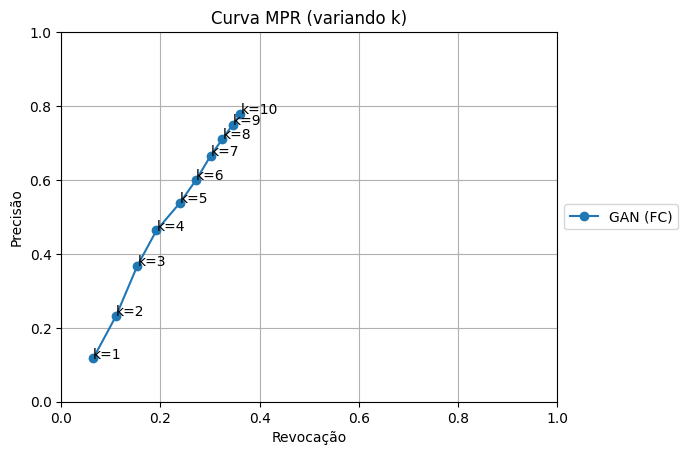

In [70]:
plot_mpr_curve(rec, prec, ks, title='Curva MPR (variando k)')   # Plota a curva MPR de revocação vs. precisão para diferentes valores de k

In [81]:
import pandas as pd
def mpr_sweep_Nk(
    mnist_test_dataset,
    gen_model,
    feature_extractor,
    Ns=(1000, 2500, 5000, 7500, 10000),
    ks=(3, 5, 10),
    *,
    model_name='EBM (Conv)',
    batch_size=512,
    z_dim=None,
    mode_z=None
) -> pd.DataFrame:

    linhas = []                                                                                         # Lista para armazenar resultados intermediários
    for N in Ns:                                                                                        # Itera pelos diferentes valores de N
        real_feats = get_features(mnist_test_dataset, feature_extractor, N=N, batch_size=batch_size)    # Extrai features reais dos primeiros N exemplos
        fake_feats = get_features_from_generator(                                                       # Extrai features de N imagens geradas
            gen_model,
            feature_extractor,
            N=N,
            z_dim=z_dim,
            mode_z=mode_z,
            batch=batch_size
        )
        for k in ks:                                                                             # Itera sobre os diferentes valores de k
            m = compute_prdc(                                                                    # Calcula métricas de precisão e revocação
                real_features=real_feats.astype('float32'),
                fake_features=fake_feats.astype('float32'),
                nearest_k=k
            )
            linhas.append({                                                                      # Adiciona linha com resultados no formato dict
                'modelo':   model_name,
                'N':        int(N),
                'k':        int(k),
                'precision':float(m['precision']),
                'recall':   float(m['recall'])
            })
            print(f"[modelo={model_name}] N={N} | k={k} -> Precisão={m['precision']:.4f} | Revocação={m['recall']:.4f}")  # Exibe no console os resultados do par (N, k)

    return pd.DataFrame(linhas)                                                                  # Retorna um DataFrame com todos os resultados

In [86]:
df_gan = mpr_sweep_Nk(                                           # Executa a varredura de N e k para calcular MPR
    mnist_test_dataset=test_ds,                               # Conjunto de teste do MNIST usado para extrair features reais
    gen_model=gen_model,                                         # Gerador treinado que produz imagens sintéticas
    feature_extractor=full_model[0],                             # Extrator de características do classificador (parte inicial do modelo)
    Ns=(1000, 2500, 5000, 7500, 10000),                          # Conjunto de valores de N a serem testados
    ks=(3, 5, 10),                                               # Conjunto de valores de k a serem testados
    model_name='EBM (Conv)',                                       # Nome do modelo para identificar os resultados no DataFrame
    batch_size=512,                                              # Tamanho dos lotes para processar dados
    z_dim=z_size,                                                # Dimensão do vetor de ruído do gerador
    mode_z=mode_z)                                               # Tipo de ruído usado (normal ou uniforme)

Num real: 1000 Num fake: 1000
[modelo=EBM (Conv)] N=1000 | k=3 -> Precisão=0.4350 | Revocação=0.1800
Num real: 1000 Num fake: 1000
[modelo=EBM (Conv)] N=1000 | k=5 -> Precisão=0.6080 | Revocação=0.2780
Num real: 1000 Num fake: 1000
[modelo=EBM (Conv)] N=1000 | k=10 -> Precisão=0.8440 | Revocação=0.4680
Num real: 2007 Num fake: 2500
[modelo=EBM (Conv)] N=2500 | k=3 -> Precisão=0.3892 | Revocação=0.1041
Num real: 2007 Num fake: 2500
[modelo=EBM (Conv)] N=2500 | k=5 -> Precisão=0.5760 | Revocação=0.2187
Num real: 2007 Num fake: 2500
[modelo=EBM (Conv)] N=2500 | k=10 -> Precisão=0.7988 | Revocação=0.3577
Num real: 2007 Num fake: 5000
[modelo=EBM (Conv)] N=5000 | k=3 -> Precisão=0.3888 | Revocação=0.1410
Num real: 2007 Num fake: 5000
[modelo=EBM (Conv)] N=5000 | k=5 -> Precisão=0.5456 | Revocação=0.2362
Num real: 2007 Num fake: 5000
[modelo=EBM (Conv)] N=5000 | k=10 -> Precisão=0.7752 | Revocação=0.3662
Num real: 2007 Num fake: 7500
[modelo=EBM (Conv)] N=7500 | k=3 -> Precisão=0.3520 | Revo

In [87]:
display(df_gan)   # Exibe o DataFrame df_gan em formato tabular

AttributeError: 'DataFrame' object has no attribute 'detach'

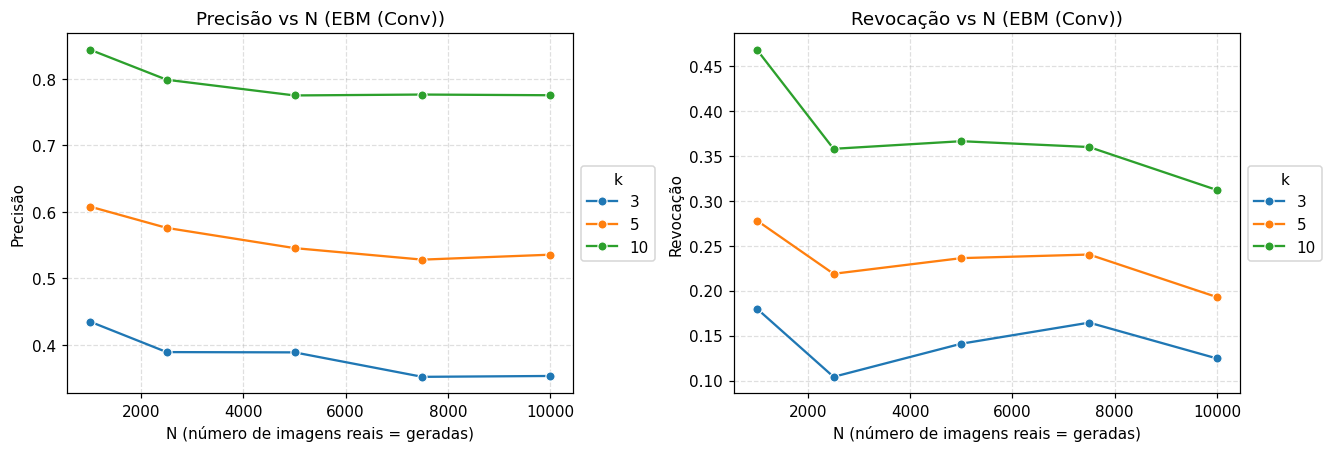

In [88]:
import seaborn as sns
def plot_mpr_df(df: pd.DataFrame):

    modelos = df['modelo'].unique().tolist()                                      # Lista os nomes únicos de modelos presentes no DataFrame
    n_models = len(modelos)                                                       # Conta quantos modelos distintos existem

    fig, axes = plt.subplots(                                                     # Cria figura com subplots
        n_models, 2,                                                              # n_models linhas, 2 colunas (Precisão e Revocação)
        figsize=(12, 4 * n_models),                                               # Ajusta o tamanho da figura proporcional ao número de modelos
        dpi=110,                                                                  # Define resolução em pontos por polegada
        constrained_layout=True                                                   # Ajusta automaticamente os espaçamentos
    )

    if n_models == 1:                                                             # Caso haja apenas 1 modelo
        axes = np.array([axes])                                                   # Garante que axes seja indexável como array bidimensional

    for i, modelo in enumerate(modelos):                                          # Itera sobre cada modelo
        df_model = df[df['modelo'] == modelo].copy()                              # Filtra o DataFrame apenas para esse modelo

        ax_left = axes[i, 0]                                                      # Eixo à esquerda para precisão
        sns.lineplot(                                                             # Plota curva de precisão
            data=df_model, x='N', y='precision',
            hue='k', marker='o', ax=ax_left,
            palette='tab10'
        )
        ax_left.set_title(f'Precisão vs N ({modelo})')                            # Título do gráfico de precisão
        ax_left.set_xlabel('N (número de imagens reais = geradas)')               # Rótulo eixo X
        ax_left.set_ylabel('Precisão')                                            # Rótulo eixo Y
        ax_left.grid(True, linestyle='--', alpha=0.4)                             # Ativa grade com estilo tracejado
        ax_left.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')     # Legenda deslocada para a direita

        ax_right = axes[i, 1]                                                     # Eixo à direita para revocação
        sns.lineplot(                                                             # Plota curva de revocação
            data=df_model, x='N', y='recall',
            hue='k', marker='o', ax=ax_right,
            palette='tab10'
        )
        ax_right.set_title(f'Revocação vs N ({modelo})')                          # Título do gráfico de revocação
        ax_right.set_xlabel('N (número de imagens reais = geradas)')              # Rótulo eixo X
        ax_right.set_ylabel('Revocação')                                          # Rótulo eixo Y
        ax_right.grid(True, linestyle='--', alpha=0.4)                            # Ativa grade com estilo tracejado
        ax_right.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')    # Legenda deslocada para a direita

    plt.show()                                                                    # Exibe a figura final com todos os subplots

plot_mpr_df(df_gan)   # Plota gráficos de Precisão e Revocação a partir do DataFrame df_gan

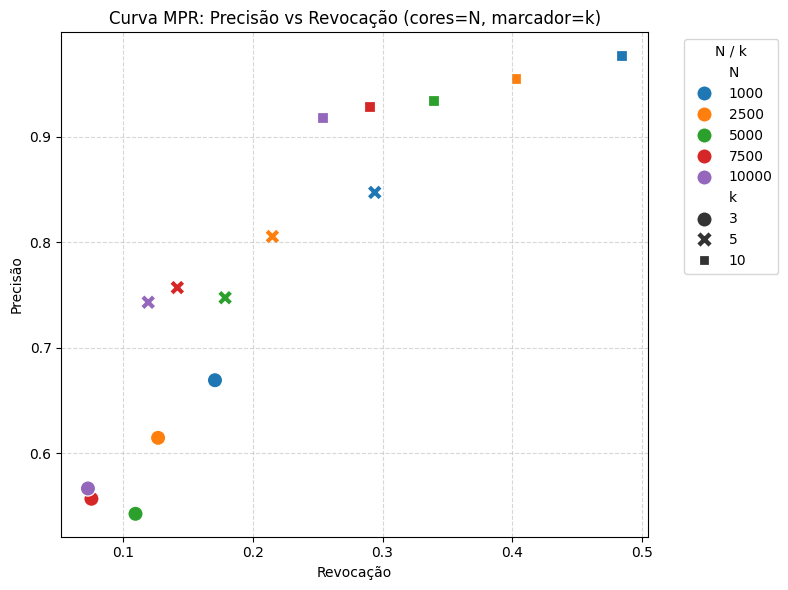

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_gan,
    x='recall',
    y='precision',
    hue='N',
    style='k',
    s=120,
    palette='tab10'
)
plt.title('Curva MPR: Precisão vs Revocação (cores=N, marcador=k)')
plt.xlabel('Revocação')
plt.ylabel('Precisão')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='N / k')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()